In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix,accuracy_score, roc_curve, auc
from sklearn.metrics import recall_score,precision_score
from sklearn.neighbors import KNeighborsClassifier
sns.set_style("whitegrid")
%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Copy of Copy of heart_attack_prediction_dataset.csv')

## **Data Cleaning & Checking**

In [ ]:
df.head()

,Patient ID,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,...,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk
0,BMW7812,67,Male,208,158/88,72,0,0,1,0,...,6.615001,261404,31.251233,286,0,6,Argentina,South America,Southern Hemisphere,0
1,CZE1114,21,Male,389,165/93,98,1,1,1,1,...,4.963459,285768,27.194973,235,1,7,Canada,North America,Northern Hemisphere,0
2,BNI9906,21,Female,324,174/99,72,1,0,0,0,...,9.463426,235282,28.176571,587,4,4,France,Europe,Northern Hemisphere,0
3,JLN3497,84,Male,383,163/100,73,1,1,1,0,...,7.648981,125640,36.464704,378,3,4,Canada,North America,Northern Hemisphere,0
4,GFO8847,66,Male,318,91/88,93,1,1,1,1,...,1.514821,160555,21.809144,231,1,5,Thailand,Asia,Northern Hemisphere,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Patient ID                       8763 non-null   object 
 1   Age                              8763 non-null   int64  
 2   Sex                              8763 non-null   object 
 3   Cholesterol                      8763 non-null   int64  
 4   Blood Pressure                   8763 non-null   object 
 5   Heart Rate                       8763 non-null   int64  
 6   Diabetes                         8763 non-null   int64  
 7   Family History                   8763 non-null   int64  
 8   Smoking                          8763 non-null   int64  
 9   Obesity                          8763 non-null   int64  
 10  Alcohol Consumption              8763 non-null   int64  
 11  Exercise Hours Per Week          8763 non-null   float64
 12  Diet                

In [ ]:
df.isnull().sum()

,0
Patient ID,0
Age,0
Sex,0
Cholesterol,0
Blood Pressure,0
Heart Rate,0
Diabetes,0
Family History,0
Smoking,0
Obesity,0


In [ ]:

heart_attack_counts = df['Heart Attack Risk'].value_counts()

heart_attack_counts

,count
Heart Attack Risk,
0,5624
1,3139


Creating histograms to visualize distribution of variables within people who are at High risk of heart attack

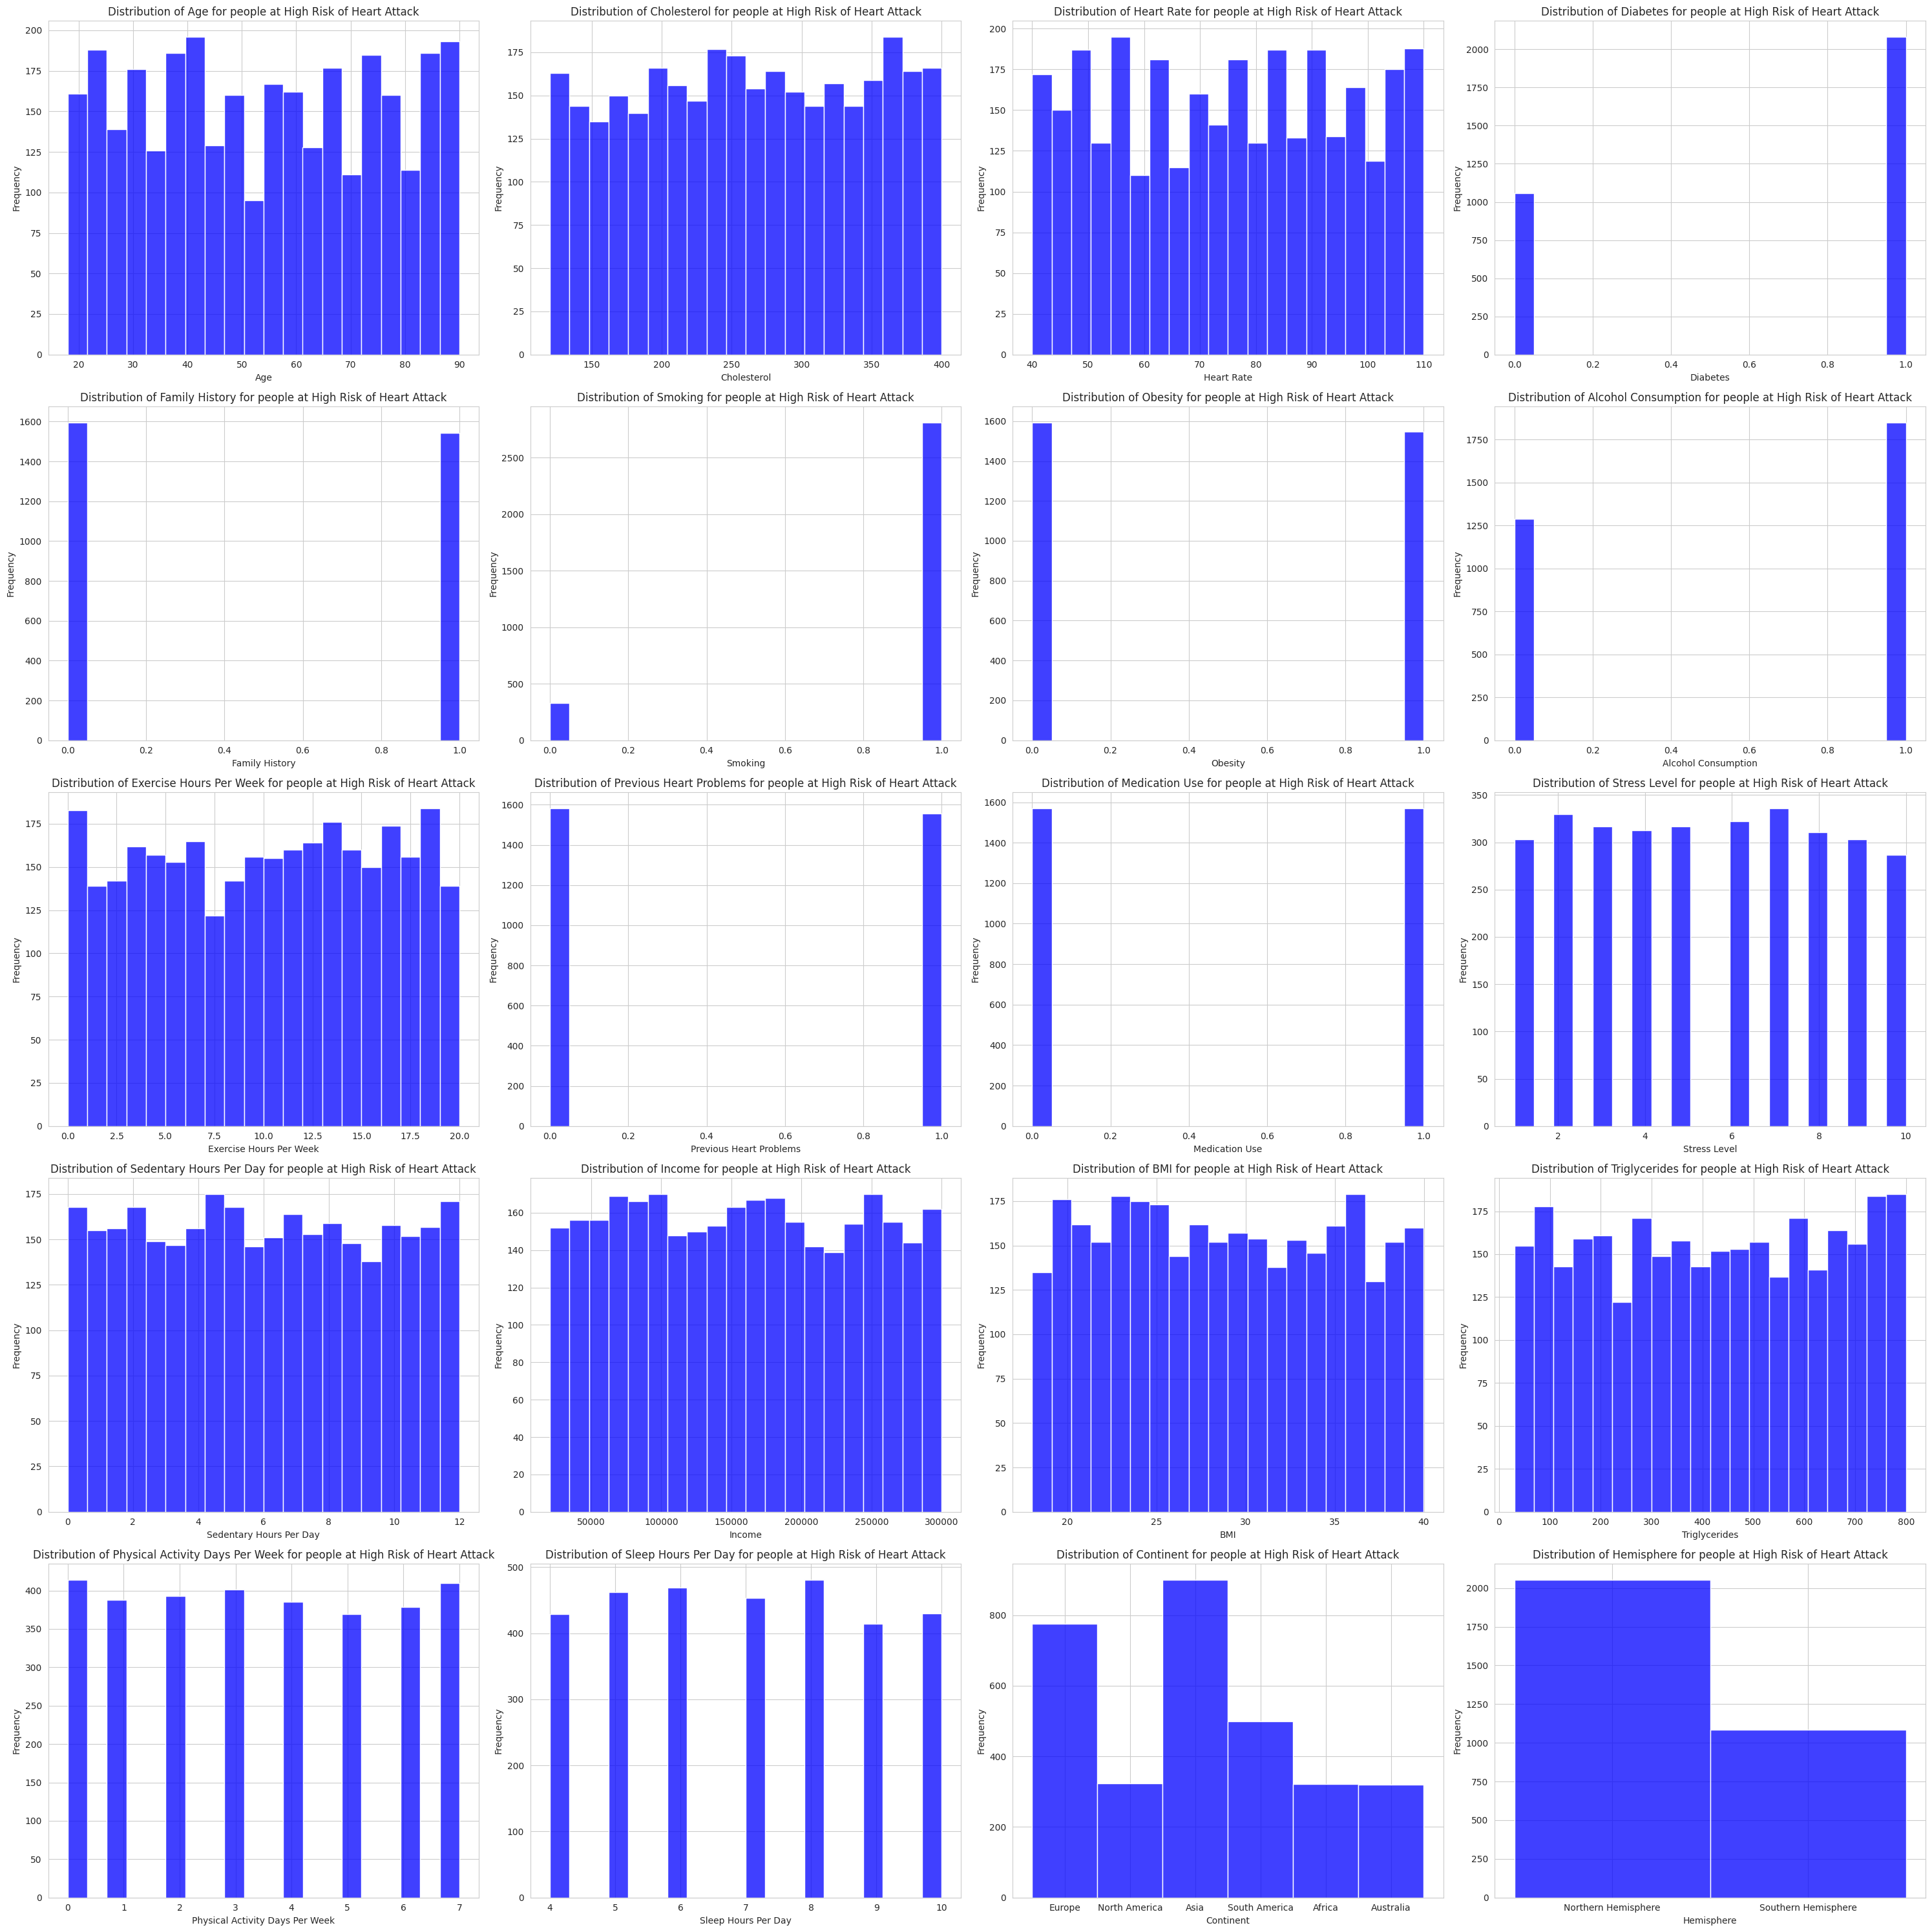

In [ ]:

key_variables = [
    'Age', 'Cholesterol', 'Heart Rate', 'Diabetes', 'Family History',
    'Smoking', 'Obesity', 'Alcohol Consumption', 'Exercise Hours Per Week',
    'Previous Heart Problems', 'Medication Use', 'Stress Level',
    'Sedentary Hours Per Day', 'Income', 'BMI', 'Triglycerides',
    'Physical Activity Days Per Week', 'Sleep Hours Per Day', "Continent", "Hemisphere"
]

high_risk_data = df[df['Heart Attack Risk'] == 1]


plt.figure(figsize=(30, 30))
for i, variable in enumerate(key_variables, start=1):
    plt.subplot(5, 4, i)
    sns.histplot(high_risk_data[variable], bins=20, color='blue')
    plt.title(f"Distribution of {variable} for people at High Risk of Heart Attack")
    plt.xlabel(variable)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

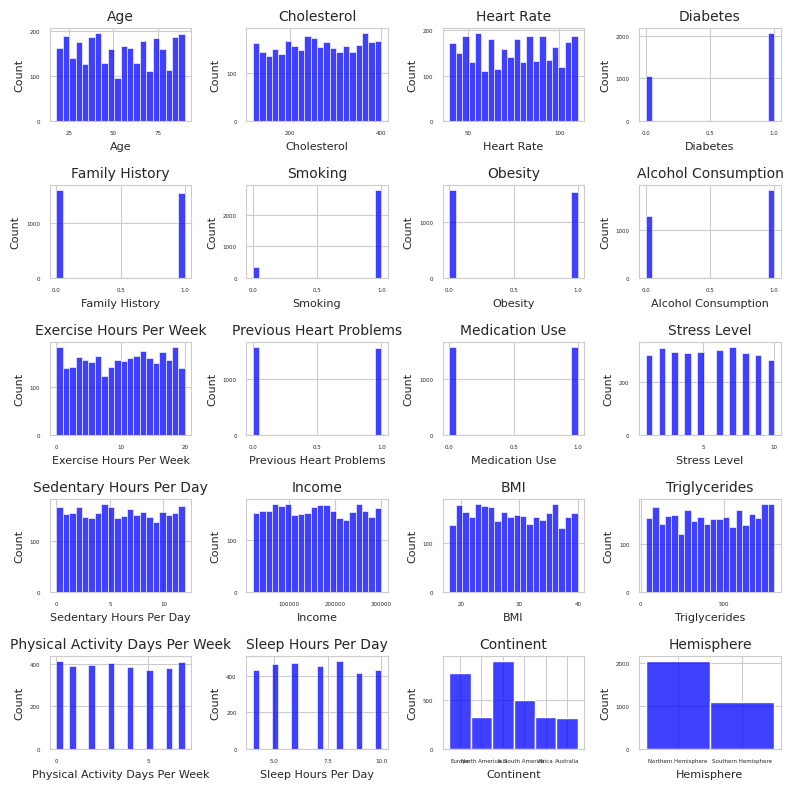

In [ ]:

key_variables = [
    'Age', 'Cholesterol', 'Heart Rate', 'Diabetes', 'Family History',
    'Smoking', 'Obesity', 'Alcohol Consumption', 'Exercise Hours Per Week',
    'Previous Heart Problems', 'Medication Use', 'Stress Level',
    'Sedentary Hours Per Day', 'Income', 'BMI', 'Triglycerides',
    'Physical Activity Days Per Week', 'Sleep Hours Per Day', "Continent", "Hemisphere"
]

high_risk_data = df[df['Heart Attack Risk'] == 1]

plt.figure(figsize=(8,8))

for i, variable in enumerate(key_variables, start=1):
    plt.subplot(5, 4, i)
    sns.histplot(high_risk_data[variable], bins=20, color='blue')
    plt.title(f"{variable}", fontsize=10)
    plt.xlabel(variable, fontsize=8)
    plt.ylabel("Count", fontsize=8)
    plt.xticks(fontsize=4)
    plt.yticks(fontsize=4)


plt.tight_layout()

plt.show()

## **Converting Categories to Binary**

In [ ]:
df = df.drop('Patient ID', axis=1)

In [ ]:
def categorize_bp(bp):
    systolic, diastolic = map(int, bp.split('/'))
    if systolic < 120 and diastolic < 80:
        return 'Normal'
    elif 120 <= systolic < 130 and diastolic < 80:
        return 'Elevated'
    elif 130 <= systolic < 140 or 80 <= diastolic < 90:
        return 'High Stage 1'
    else:
        return 'High Stage 2'

df['BP_Category'] = df['Blood Pressure'].apply(categorize_bp)
df = df.drop(columns=['Blood Pressure'])

In [ ]:
df = pd.get_dummies(df, drop_first=True).astype(int)

In [ ]:
df.head(10)

,Age,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Previous Heart Problems,...,Country_Vietnam,Continent_Asia,Continent_Australia,Continent_Europe,Continent_North America,Continent_South America,Hemisphere_Southern Hemisphere,BP_Category_High Stage 1,BP_Category_High Stage 2,BP_Category_Normal
0,67,208,72,0,0,1,0,0,4,0,...,0,0,0,0,0,1,1,1,0,0
1,21,389,98,1,1,1,1,1,1,1,...,0,0,0,0,1,0,0,0,1,0
2,21,324,72,1,0,0,0,0,2,1,...,0,0,0,1,0,0,0,0,1,0
3,84,383,73,1,1,1,0,1,9,1,...,0,0,0,0,1,0,0,0,1,0
4,66,318,93,1,1,1,1,0,5,1,...,0,1,0,0,0,0,0,1,0,0
5,54,297,48,1,1,1,0,1,0,1,...,0,0,0,1,0,0,0,1,0,0
6,90,358,84,0,0,1,0,1,4,0,...,0,0,0,0,1,0,0,0,0,1
7,84,220,107,0,0,1,1,1,3,0,...,0,1,0,0,0,0,0,1,0,0
8,20,145,68,1,0,1,1,0,16,0,...,0,0,0,0,0,1,1,0,1,0
9,43,248,55,0,1,1,1,1,0,0,...,0,1,0,0,0,0,0,0,1,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 50 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   Age                              8763 non-null   int64
 1   Cholesterol                      8763 non-null   int64
 2   Heart Rate                       8763 non-null   int64
 3   Diabetes                         8763 non-null   int64
 4   Family History                   8763 non-null   int64
 5   Smoking                          8763 non-null   int64
 6   Obesity                          8763 non-null   int64
 7   Alcohol Consumption              8763 non-null   int64
 8   Exercise Hours Per Week          8763 non-null   int64
 9   Previous Heart Problems          8763 non-null   int64
 10  Medication Use                   8763 non-null   int64
 11  Stress Level                     8763 non-null   int64
 12  Sedentary Hours Per Day          8763 non-null  

# **Machine Learning program to predict likelyhood of Heart Attack**

In [ ]:
from sklearn.feature_selection import SelectFromModel
from sklearn.tree import DecisionTreeClassifier

In [ ]:
X = df.drop(columns=['Heart Attack Risk'])
y = df['Heart Attack Risk']
print(X.shape)
print(y.shape)

(8763, 49)
(8763,)


In [ ]:
# Split data into training and testing sets (80% training, 20% testing)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
model = DecisionTreeClassifier(criterion="entropy")
model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy')

In [ ]:
class_counts = y_test.value_counts()
total = len(y_test)
class_distribution = (class_counts / total) * 100
print("Class Distribution:\n", class_distribution)

Class Distribution:
 Heart Attack Risk
0    64.175699
1    35.824301
Name: count, dtype: float64


In [ ]:
y_train_pred = model.predict(X_train)
y_test_pred  = model.predict(X_test)

In [ ]:
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred  = model.predict(X_test)

# **Decision Tree (Trial One)**

Train Accuracy: 0.64
Test Accuracy: 0.64

Classification Report (Test):
              precision    recall  f1-score   support

    low risk       0.64      1.00      0.78      1125
   high risk       0.25      0.00      0.00       628

    accuracy                           0.64      1753
   macro avg       0.45      0.50      0.39      1753
weighted avg       0.50      0.64      0.50      1753



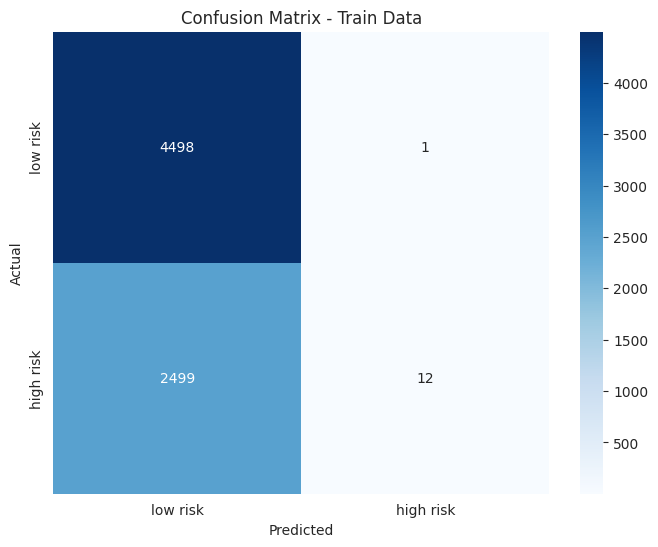

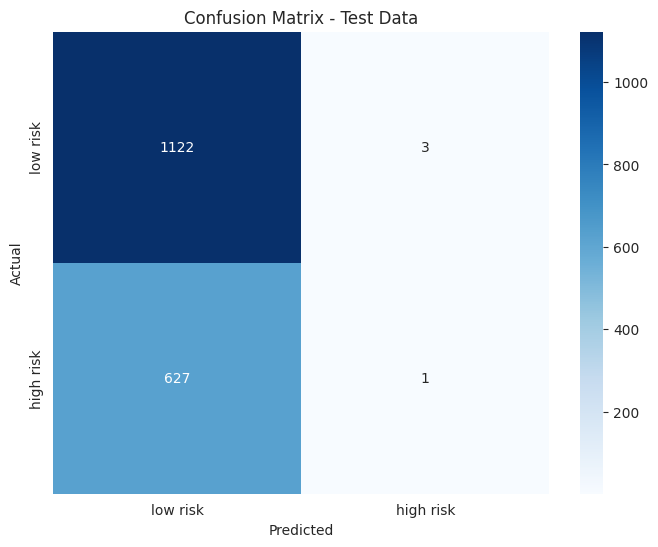

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

classes = ['low risk', 'high risk']
dt_clf = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    random_state=42
)
dt_clf.fit(X_train, y_train)

y_train_pred = dt_clf.predict(X_train)
y_test_pred = dt_clf.predict(X_test)

print(f"Train Accuracy: {accuracy_score(y_train, y_train_pred):.2f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred):.2f}")
print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred, target_names=classes))

def plot_confusionmatrix(y_actual, y_pred, title):
    conf_matrix = confusion_matrix(y_actual, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_confusionmatrix(y_train, y_train_pred, "Confusion Matrix - Train Data")
plot_confusionmatrix(y_test, y_test_pred, "Confusion Matrix - Test Data")



Training and Testing accuracy is the same so there is no overfitting occuring. However, the model's preformance is low in handling the high risk class. Low risk is predicted accuurately. The model is heavily biased towards low risk because of the class imbalance in the data.	The macro average F1-score (39%) reflects the poor performance on the high risk.
Low Risk
* Precision: 64% – Of all predictions for “low risk,” 64% were correct.
* Recall: 100% – The model captured all actual “low risk” cases perfectly.

High Risk:
* Precision: 25% – Of all predictions for “high risk,” only 25% were correct.
* Recall: 0% – The model failed to capture actual “high risk” cases in the test data.


Most important Variables:
                            Feature  Importance
13                           Income    0.281498
17              Sleep Hours Per Day    0.106579
1                       Cholesterol    0.106482
38            Country_United States    0.083641
2                        Heart Rate    0.067106
15                    Triglycerides    0.065698
0                               Age    0.062901
14                              BMI    0.061682
16  Physical Activity Days Per Week    0.058173
8           Exercise Hours Per Week    0.053147
26                   Country_France    0.053095
37           Country_United Kingdom    0.000000
31              Country_New Zealand    0.000000
32                  Country_Nigeria    0.000000
47         BP_Category_High Stage 2    0.000000
33             Country_South Africa    0.000000
34              Country_South Korea    0.000000
35                    Country_Spain    0.000000
36                 Country_Thailand    0.000000
46         BP_

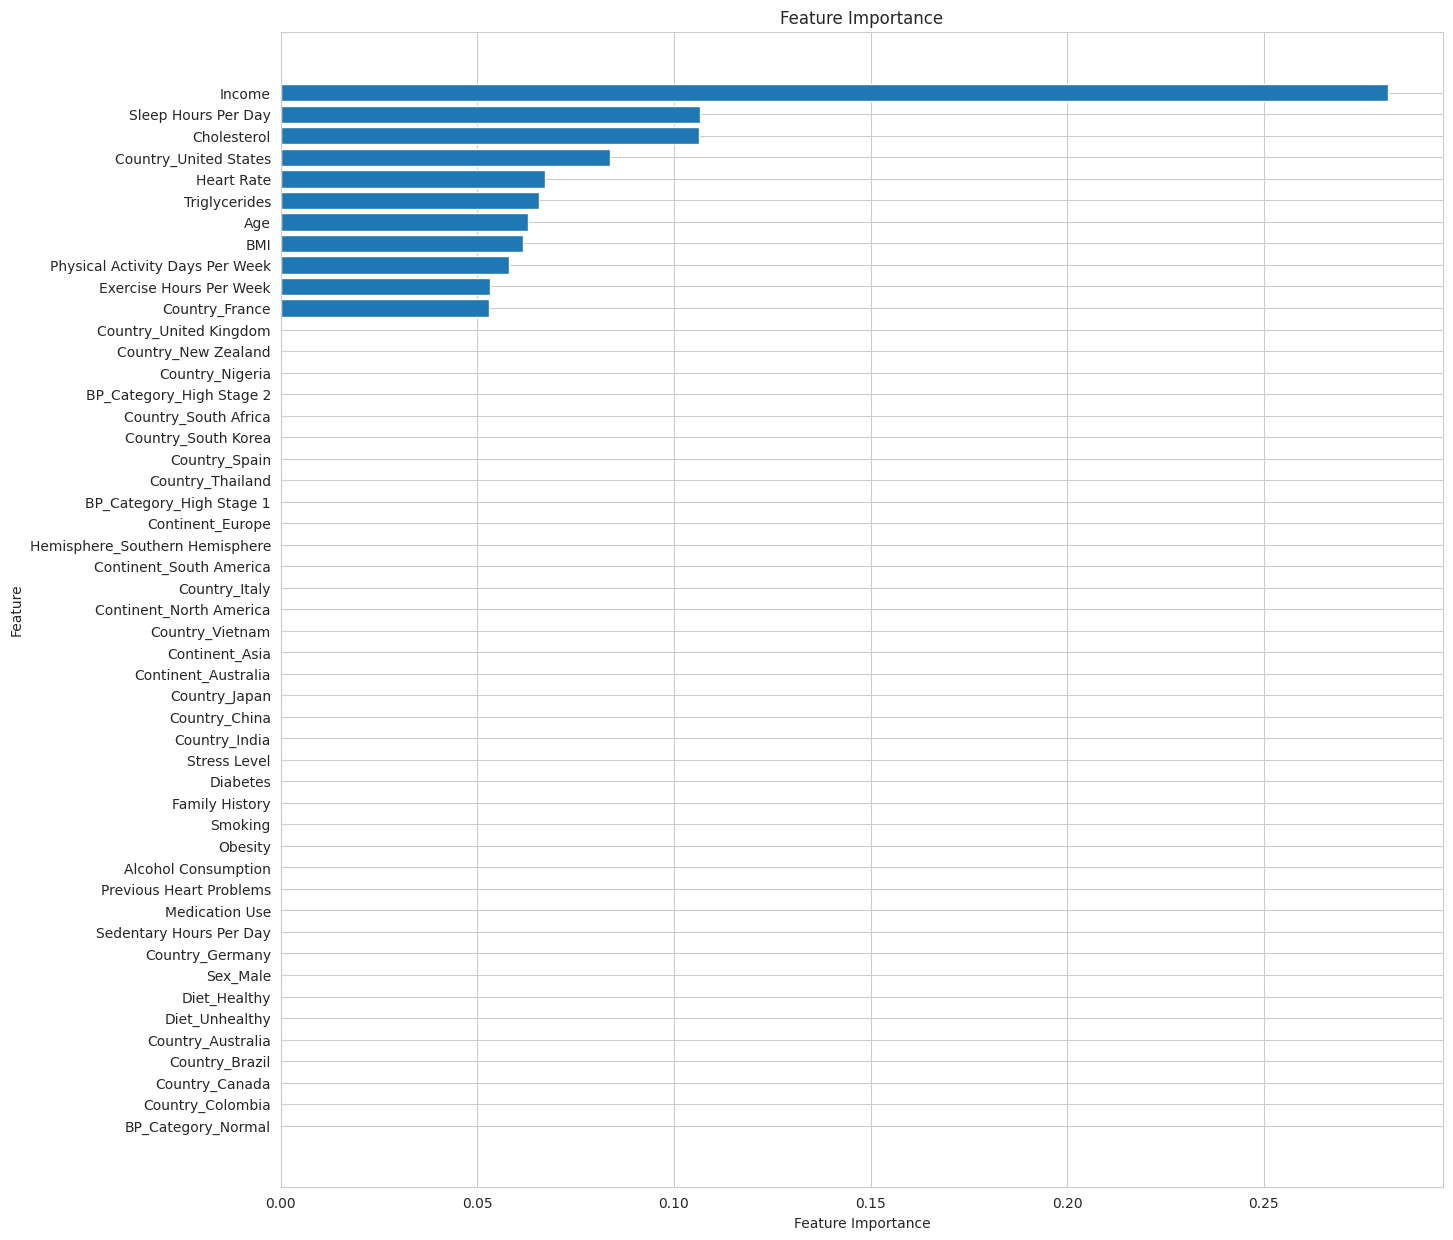

In [ ]:
# Ranking the Importance
feature_importances = dt_clf.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

print("Most important Variables:")
print(feature_importance_df)

plt.figure(figsize=(15, 15))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Feature Importance")
plt.gca().invert_yaxis()
plt.show()

Top 8 Features: ['Income', 'Sleep Hours Per Day', 'Cholesterol', 'Country_United States', 'Heart Rate', 'Triglycerides', 'Age', 'BMI', 'Physical Activity Days Per Week', 'Exercise Hours Per Week', 'Country_France']


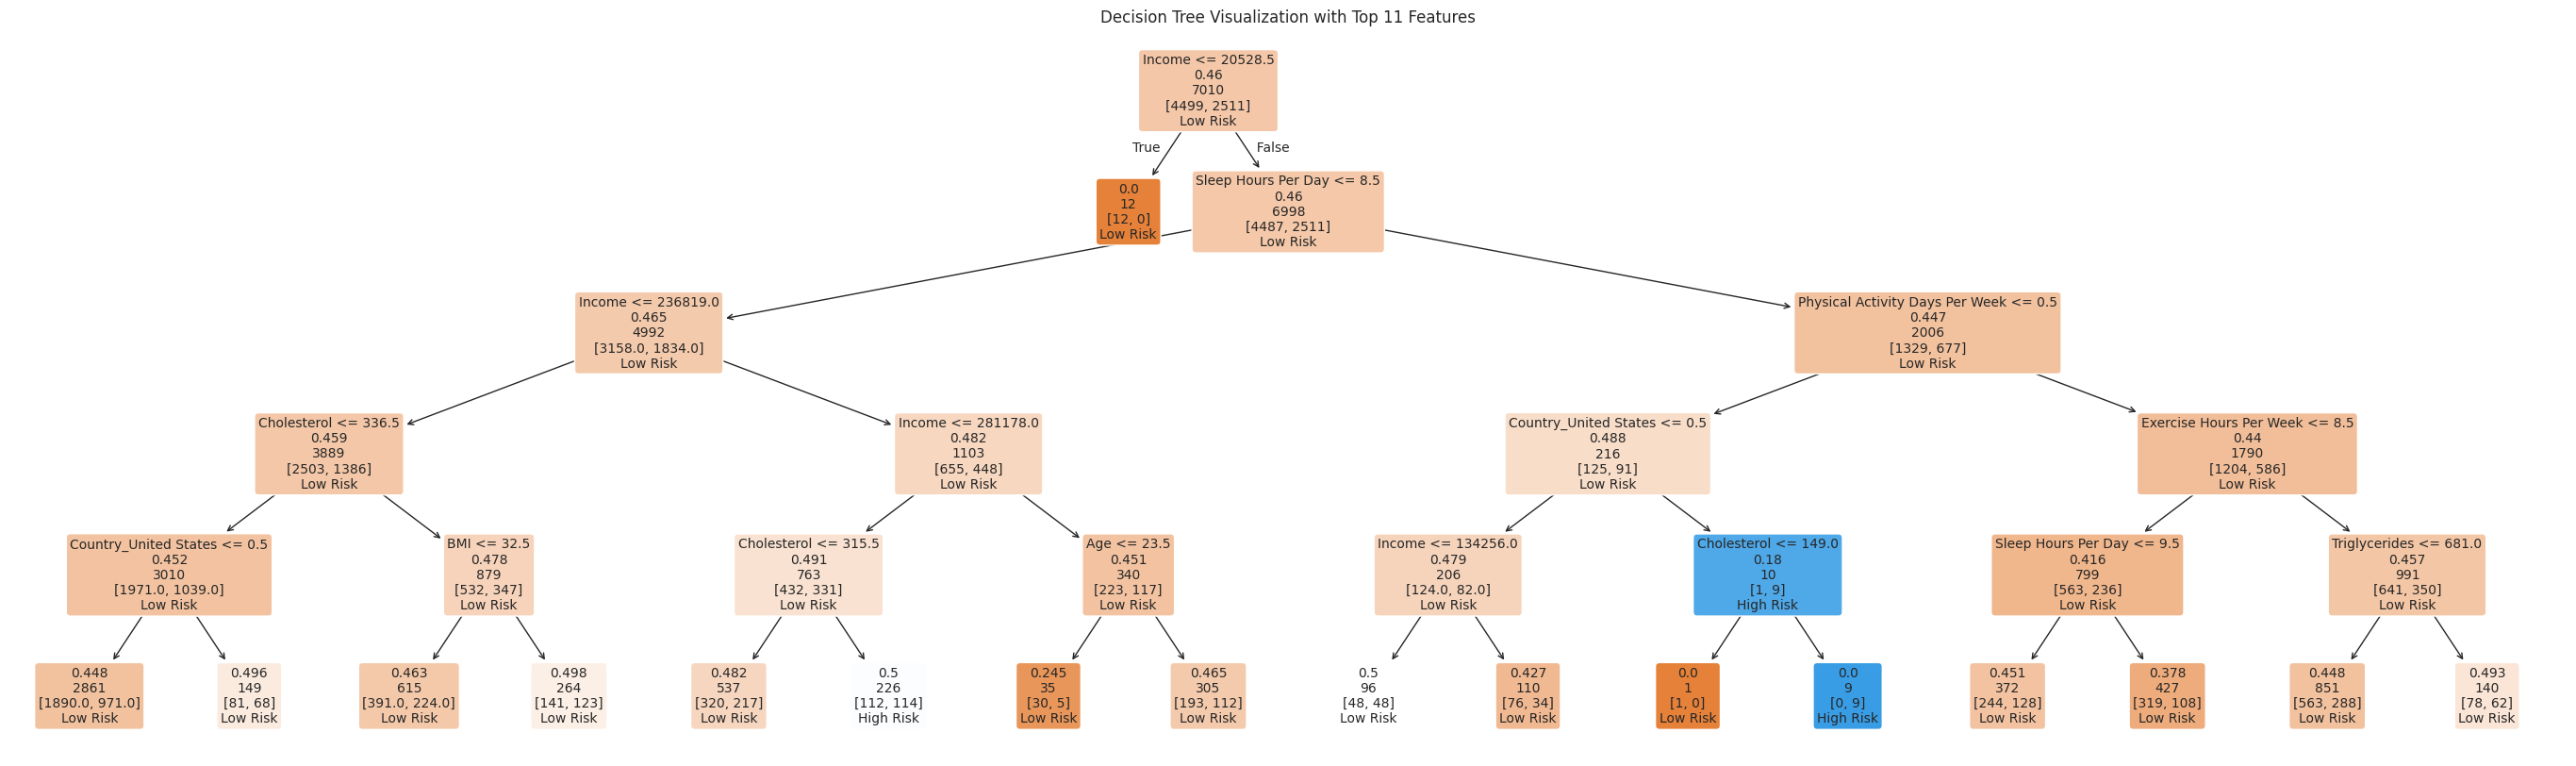

In [ ]:
top_features = (feature_importance_df['Feature'].head(11)).tolist()
print(f"Top 8 Features: {top_features}")
X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

dt_clf_top = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    random_state=42
)
dt_clf_top.fit(X_train_top, y_train)

plt.figure(figsize=(35, 10))
plot_tree(
    dt_clf_top,
    feature_names=top_features,
    class_names = ['Low Risk', 'High Risk'],
    filled=True,
    rounded=True,
    fontsize=10,
    label = 'none'
)
plt.title("Decision Tree Visualization with Top 11 Features")
plt.show()

data is not balanced (low risk accuracy is much higher than high risk)

### Balancing the Data using Random Under Samplying sets as low risk has many more values than high risk

In [ ]:
!pip install imblearn

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

Class Distribution in Balanced Training Set:
Heart Attack Risk
0    2197
1    2197
Name: count, dtype: int64
Train Accuracy: 0.55
Test Accuracy: 0.44

Classification Report (Test):
              precision    recall  f1-score   support

    low risk       0.64      0.31      0.41      1687
   high risk       0.36      0.68      0.47       942

    accuracy                           0.44      2629
   macro avg       0.50      0.50      0.44      2629
weighted avg       0.54      0.44      0.43      2629



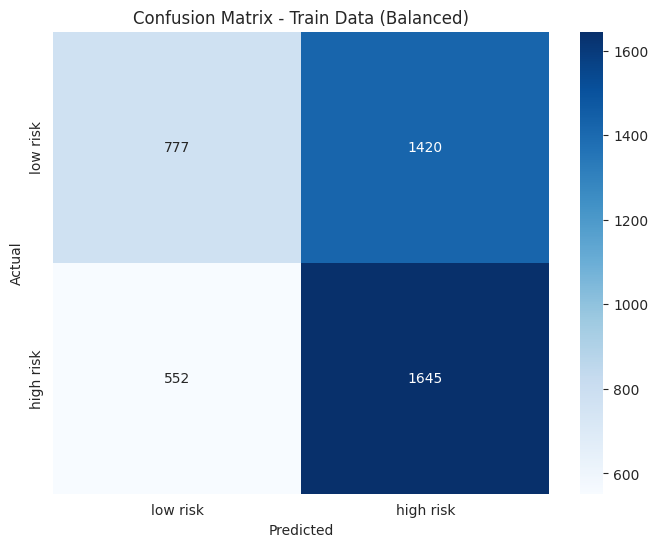

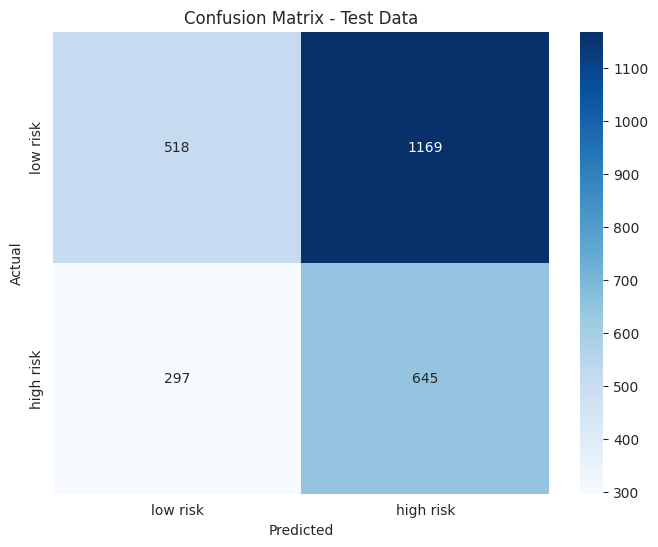

In [ ]:


# Step 2: Balance the Training Set
undersampler = RandomUnderSampler(random_state=42)
X_train_balanced, y_train_balanced = undersampler.fit_resample(X_train, y_train)

print(f"Class Distribution in Balanced Training Set:\n{pd.Series(y_train_balanced).value_counts()}")

# Step 3: Train a Decision Tree on the Balanced Dataset
dt_clf = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    random_state=42
)
dt_clf.fit(X_train_balanced, y_train_balanced)

y_train_pred = dt_clf.predict(X_train_balanced)
y_test_pred = dt_clf.predict(X_test)

print(f"Train Accuracy: {accuracy_score(y_train_balanced, y_train_pred):.2f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred):.2f}")
print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred, target_names=classes))

def plot_confusionmatrix(y_actual, y_pred, title):
    conf_matrix = confusion_matrix(y_actual, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_confusionmatrix(y_train_balanced, y_train_pred, "Confusion Matrix - Train Data (Balanced)")
plot_confusionmatrix(y_test, y_test_pred, "Confusion Matrix - Test Data")


To address the class imbalance problem in the dataset (where “low risk” cases heavily outnumber “high risk” cases), we used Random Undersampling. This technique reduces the number of majority class samples (“low risk”) to match the number of minority class samples (“high risk”), creating a balanced training set.
The undersampler balanced the training set:
*	“Low Risk”: 2197 samples
* “High Risk”: 2197 samples
* This ensures the model is trained with equal representation of both classes, improving its ability to predict “high risk” cases.

Train Accuracy: 55%

* The model underperformed on the training set compared to its baseline version (64% accuracy before balancing). This is expected since balancing reduces the model’s exposure to the majority class.

Test Accuracy: 44%

* The test accuracy dropped significantly, indicating that while the model is now better at identifying “high risk” cases, it struggles to generalize to unseen data.

* Recall for “High Risk” Improved: The model is better at capturing true positives for “high risk” cases compared to the baseline version. However, there was a trade off in precision and recall for low risk cases




### **Trying to use SMOTE to Balance the Dataset to see if this will drop the accuracy more**

•	Random Undersampling reduced the amount of data available for training, which likely contributed to the drop in performance. To address this limitation, I decided to use SMOTE (Synthetic Minority Oversampling Technique) to balance the training dataset. SMOTE retains all samples from the majority class while addressing class imbalance.By synthetically generating new samples, SMOTE ensures the model has more exposure to “high risk” cases, leading to better recall.

In [ ]:
!pip install imbalanced-learn

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

Class Distribution in Balanced Training Set:
Heart Attack Risk
0    4499
1    4499
Name: count, dtype: int64
Train Accuracy: 0.64
Test Accuracy: 0.56

Classification Report (Test):
              precision    recall  f1-score   support

    Low Risk       0.64      0.74      0.69      1125
   High Risk       0.35      0.25      0.29       628

    accuracy                           0.56      1753
   macro avg       0.49      0.49      0.49      1753
weighted avg       0.53      0.56      0.54      1753



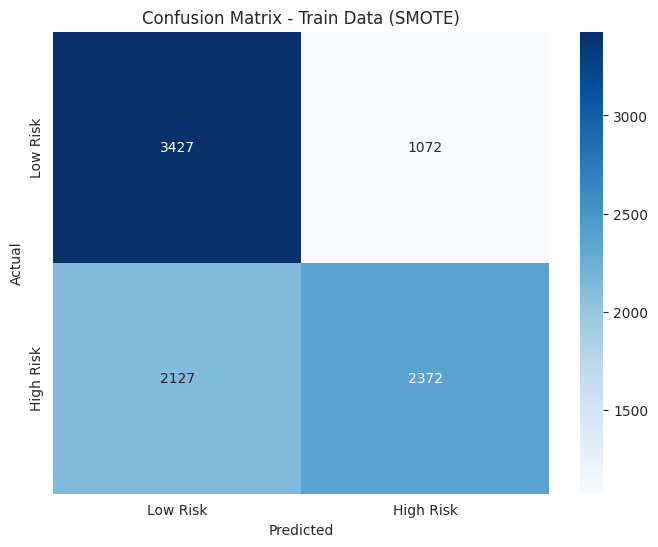

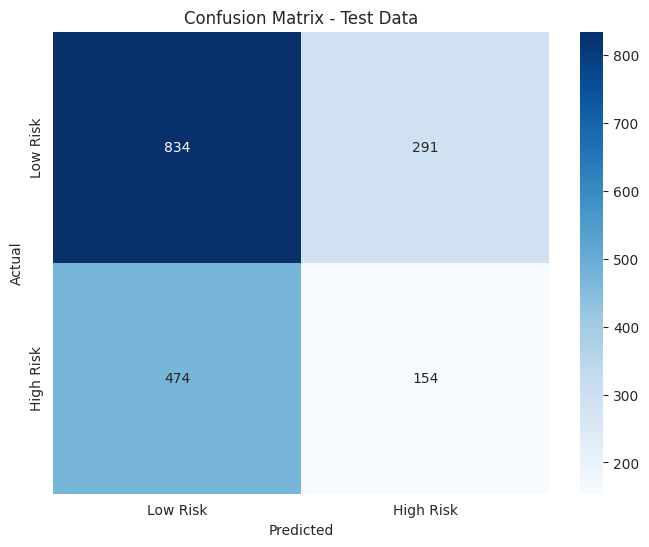

In [ ]:

from imblearn.over_sampling import SMOTE # Import SMOTE


smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Class Distribution in Balanced Training Set:\n{pd.Series(y_train_smote).value_counts()}")

dt_clf = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    random_state=42
)
dt_clf.fit(X_train_smote, y_train_smote)

classes = ['Low Risk', 'High Risk']

y_train_pred = dt_clf.predict(X_train_smote)
y_test_pred = dt_clf.predict(X_test)

print(f"Train Accuracy: {accuracy_score(y_train_smote, y_train_pred):.2f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred):.2f}")
print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred, target_names=classes))

def plot_confusionmatrix(y_actual, y_pred, title):
    conf_matrix = confusion_matrix(y_actual, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_confusionmatrix(y_train_smote, y_train_pred, "Confusion Matrix - Train Data (SMOTE)")
plot_confusionmatrix(y_test, y_test_pred, "Confusion Matrix - Test Data")



Train Accuracy: 64% : The train accuracy is comparable to the baseline (without class balancing) but higher than the Random Undersampling version (55%).
Test Accuracy: 56% :Test accuracy improved slightly compared to the Random Undersampling version (44%) but remains below the baseline accuracy (64%).

Classification Report (Test Data):

Low Risk:
* Precision: 64% – Indicates that 64% of the predictions for “low risk” are correct.
* Recall: 74% – The model correctly identified 74% of actual “low risk” cases.

High Risk:
* Precision: 35% – Indicates the model struggles with “high risk” precision, likely due to overlapping samples created by SMOTE.
* Recall: 25% – This is lower than the recall achieved using Random Undersampling (68%), suggesting SMOTE helped generate synthetic examples but failed to improve the minority class significantly on the test set.

Comparasion with Previous Results

Random Undersampling
* Random Undersampling increased recall for “high risk” cases (68%) but at the cost of precision (36%) and overall accuracy.
* The removal of majority class samples reduced the ability of the model to generalize to “low risk” cases, reflected in a poor overall test performance.

SMOTE improved precision and recall for “low risk” cases compared to Random Undersampling, but at the expense of precision for “high risk” cases.

Baseline Model
* Test accuracy is alot lower at 56% compared to 64%, train accuracy stays the same.

Observations:

* Precision and recall for “high risk” cases improved compared to the baseline but were lower than Random Undersampling’s recall.
* SMOTE generated overlapping synthetic data points, which may have confused the model on unseen test data.

Train data is much better now, more evenly distributed. Test is doing well with low risk predicted and accurated but is sitll not doing a good job with high risk predicted and actual. Smote preformed better than random under samplying. (This one seems to have the best results so far).

### **Adjusting the max depth to 8**

We are adjusting the max depth to 8 (creating a deep tree) to allow the tree to create more splits and capture more patterns that may have been missed with a shallower depth of 5.

Class Distribution in Balanced Training Set:
Heart Attack Risk
0    4499
1    4499
Name: count, dtype: int64
Train Accuracy: 0.71
Test Accuracy: 0.58

Classification Report (Test):
              precision    recall  f1-score   support

    Low Risk       0.65      0.74      0.69      1125
   High Risk       0.38      0.29      0.33       628

    accuracy                           0.58      1753
   macro avg       0.52      0.51      0.51      1753
weighted avg       0.55      0.58      0.56      1753



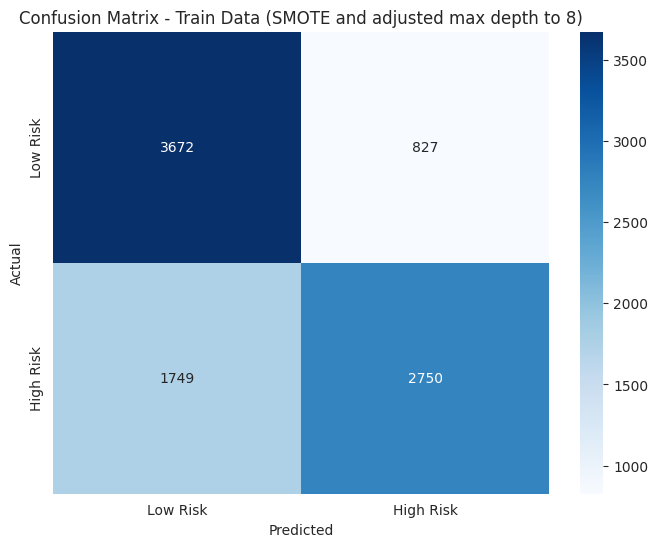

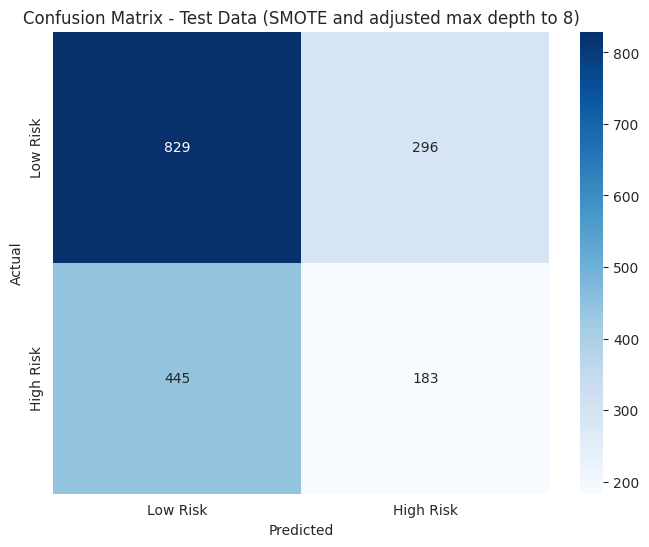

In [ ]:

print(f"Class Distribution in Balanced Training Set:\n{pd.Series(y_train_smote).value_counts()}")


dt_clf = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=8,
    random_state=42
)
dt_clf.fit(X_train_smote, y_train_smote)
classes = ['Low Risk', 'High Risk']

y_train_pred = dt_clf.predict(X_train_smote)
y_test_pred = dt_clf.predict(X_test)

print(f"Train Accuracy: {accuracy_score(y_train_smote, y_train_pred):.2f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred):.2f}")
print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred, target_names=classes))

def plot_confusionmatrix(y_actual, y_pred, title):
    conf_matrix = confusion_matrix(y_actual, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_confusionmatrix(y_train_smote, y_train_pred, "Confusion Matrix - Train Data (SMOTE and adjusted max depth to 8)")
plot_confusionmatrix(y_test, y_test_pred, "Confusion Matrix - Test Data (SMOTE and adjusted max depth to 8)")



Train Accuracy: 71%

* The model achieves a relatively high training accuracy, indicating that it is learning more detailed patterns compared to max_depth=5.

Test Accuracy: 58%

* Test accuracy is slightly higher than max_depth=5, suggesting that the additional depth might not significantly improve generalization on unseen test data.

Classification Report (Test Data):

Low Risk:
*Precision: 65% – Similar to previous iterations.
* Recall: 74% – Consistent with prior results, the model correctly identifies most “low risk” cases.

High Risk:
* Precision: 38% – The precision for “high risk” remains low, indicating many false positives. There is a slight improvement from 35% after implementig SMOTE
* Recall: 29% – This is the same as the result with max_depth=5, showing that increasing the depth did not improve sensitivity for “high risk.”
The significant false negatives for “high risk” cases (1749) indicate that even with deeper trees, the model struggles with this class.



### **Apply L1 Regularization for Feature Selection to see if that will help**

Since our data has a large number of feature (some of which are irrelevant) we will try and apply L1 Regularization to improve generalization by focusing on the most important predictors and get better test preformance and hope to increase the accuracy

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


Selected Features (Indices): [ 0  1  2  3  4  6  7  8  9 10 11 12 14 15 16 17 18 19 20 40 42 45 46 47
 48]
Selected Features (Names): Index(['Age', 'Cholesterol', 'Heart Rate', 'Diabetes', 'Family History',
       'Obesity', 'Alcohol Consumption', 'Exercise Hours Per Week',
       'Previous Heart Problems', 'Medication Use', 'Stress Level',
       'Sedentary Hours Per Day', 'BMI', 'Triglycerides',
       'Physical Activity Days Per Week', 'Sleep Hours Per Day', 'Sex_Male',
       'Diet_Healthy', 'Diet_Unhealthy', 'Continent_Asia', 'Continent_Europe',
       'Hemisphere_Southern Hemisphere', 'BP_Category_High Stage 1',
       'BP_Category_High Stage 2', 'BP_Category_Normal'],
      dtype='object')
Train Accuracy: 0.64
Test Accuracy: 0.55

Classification Report (Test):
              precision    recall  f1-score   support

    low risk       0.65      0.65      0.65      1687
   high risk       0.37      0.37      0.37       942

    accuracy                           0.55      2629
   m

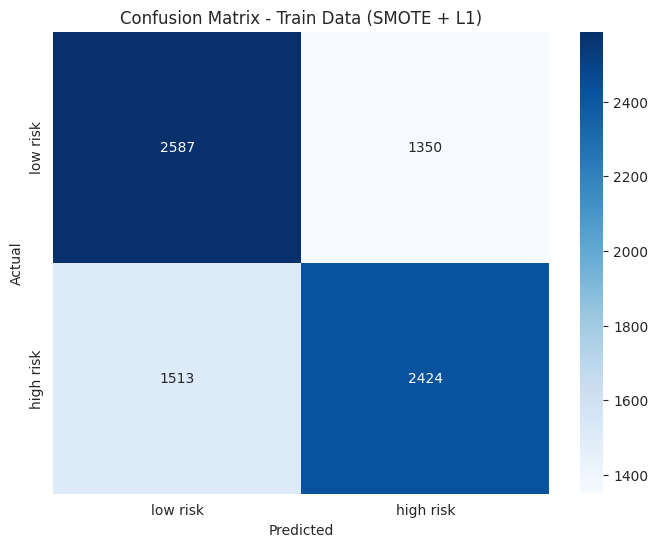

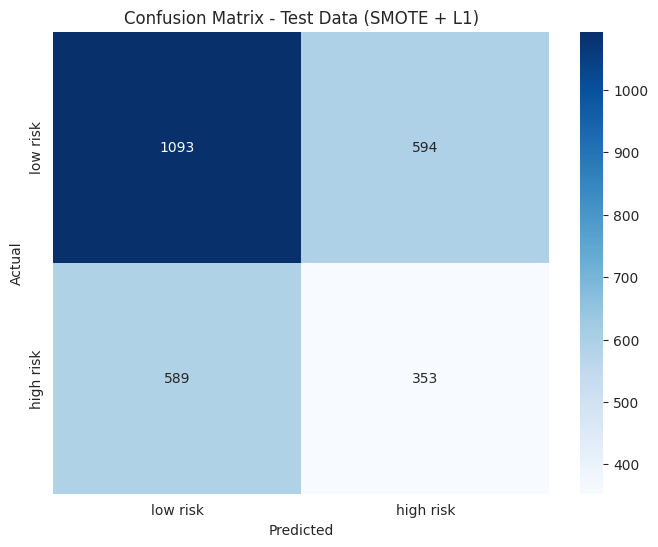

In [ ]:

# Apply L1 Regularization for Feature Selection
lasso = LogisticRegression(penalty='l1', solver='liblinear', random_state=42, C=0.01)
lasso.fit(X_train_smote, y_train_smote)
ctFromModel(lasso, prefit=True)
X_train_smote_selected = model.transform(X_train_smote)
X_test_selected = model.transform(X_test)

# Get the selected features
selected_features = model.get_support(indices=True)
print(f"Selected Features (Indices): {selected_features}")
print(f"Selected Features (Names): {X.columns[selected_features]}")

# Train a Decision Tree on the Selected Features
dt_clf = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    random_state=42
)
dt_clf.fit(X_train_smote_selected, y_train_smote)

y_train_pred = dt_clf.predict(X_train_smote_selected)
y_test_pred = dt_clf.predict(X_test_selected)

print(f"Train Accuracy: {accuracy_score(y_train_smote, y_train_pred):.2f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred):.2f}")
print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred, target_names=classes))

def plot_confusionmatrix(y_actual, y_pred, title):
    conf_matrix = confusion_matrix(y_actual, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_confusionmatrix(y_train_smote, y_train_pred, "Confusion Matrix - Train Data (SMOTE + L1)")
plot_confusionmatrix(y_test, y_test_pred, "Confusion Matrix - Test Data (SMOTE + L1)")

L1 identified 23 important features frmo the original feature set and focusing on more important variables.

Compared to the pure SMOTE model, train and test accuracies slightly decreased, indicating a simpler, more interpretable model that avoids overfitting.

High-Risk Recall: Remained similar to the SMOTE-only model, showing the model’s continued ability to identify more high-risk cases than earlier iterations.

High-Risk Precision: Improved slightly but still indicates a relatively high rate of false positives in the test set.

True positives for the high-risk class increased slightly compared to the baseline and other models.

The reduction in features may have minimized the noise but failed to completely resolve the test data imbalance challenges.

class imbalance n the test data set is still occuring.

## **Trying Hyperparameter Tuning For Decision Tree**

Hyperparameter tuning searches for the best combination of parameters to optimize the model’s ability to generalize to unseen data, we wil try to to improve both accuracy and recall.

Fitting 5 folds for each of 160 candidates, totalling 800 fits
Best Parameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best F1 Score: 0.5930419403395444
Train Accuracy: 1.00
Test Accuracy: 0.52

Classification Report (Test Set):
              precision    recall  f1-score   support

    Low Risk       0.64      0.58      0.61      1125
   High Risk       0.36      0.42      0.38       628

    accuracy                           0.52      1753
   macro avg       0.50      0.50      0.50      1753
weighted avg       0.54      0.52      0.53      1753



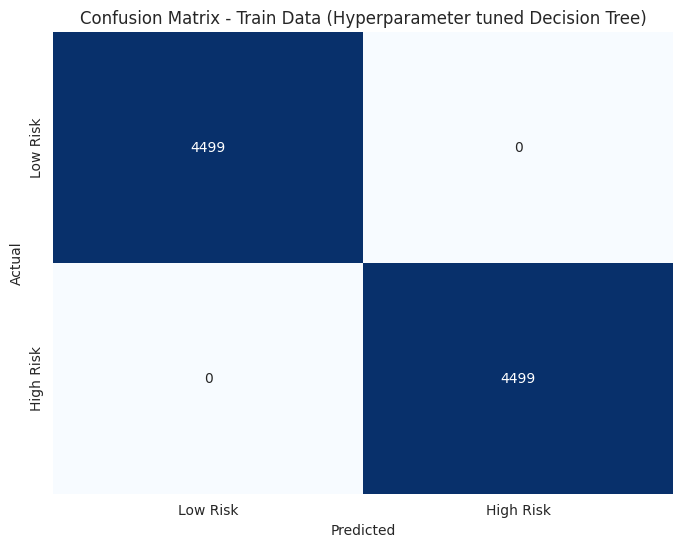

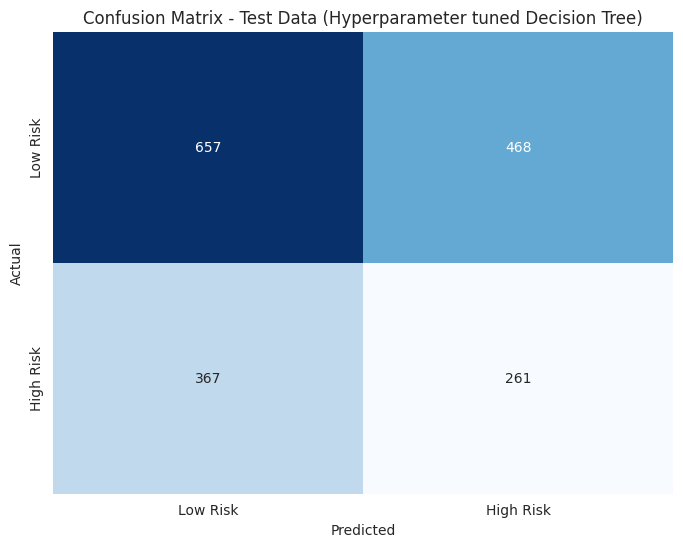

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'criterion': ['gini', 'entropy'],  # Measure for splitting
    'max_depth': [3, 5, 7, 10, None],  # Maximum depth of the tree
    'min_samples_split': [2, 5, 10, 20],  # Minimum samples required to split a node
    'min_samples_leaf': [1, 2, 5, 10]  # Minimum samples in a leaf
}

# Initialize the model
dt_clf = DecisionTreeClassifier(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=dt_clf,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    verbose=1,
    n_jobs=-1
)

# Fit GridSearchCV
grid_search.fit(X_train_smote, y_train_smote)

# Display the best parameters and the best score
print("Best Parameters:", grid_search.best_params_)
print("Best F1 Score:", grid_search.best_score_)

# Train a Decision Tree with the best parameters
best_dt_clf = grid_search.best_estimator_

y_train_pred = best_dt_clf.predict(X_train_smote)
y_test_pred = best_dt_clf.predict(X_test)

print(f"Train Accuracy: {accuracy_score(y_train_smote, y_train_pred):.2f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred):.2f}")

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred, target_names=classes))

plot_confusionmatrix(y_train_smote, y_train_pred, "Confusion Matrix - Train Data (Hyperparameter tuned Decision Tree)")
plot_confusionmatrix(y_test, y_test_pred, "Confusion Matrix - Test Data (Hyperparameter tuned Decision Tree)")

Train Accuracy: 0.60 | Test Accuracy: 0.55
Confusion Matrix:
Training:
“High Risk” recall improved
More “Low Risk” cases misclassified as “High Risk” compared to earlier models, showing a shift toward better balance.

Testing:
“High Risk” recall: 0.31 (slightly better than SMOTE + L1).
The misclassification rate for “High Risk” remained substantial, though recall and F1-score improved slightly.

Improvements that have been notized

The simpler tree structure reduced overfitting, improving “High Risk” identification slightly.

A difficulty faces is that there is constant imbalance in the test data which limits the model's ability to generalize for "High Risk"

Trying a Different Model other than Decision Tree

### **Trying Random Forest Method**

Train Accuracy (Unweighted): 1.00
Test Accuracy (Unweighted): 0.64

Classification Report (Test Set - Unweighted Random Forest):
              precision    recall  f1-score   support

    Low Risk       0.64      0.98      0.78      1125
   High Risk       0.44      0.02      0.04       628

    accuracy                           0.64      1753
   macro avg       0.54      0.50      0.41      1753
weighted avg       0.57      0.64      0.51      1753



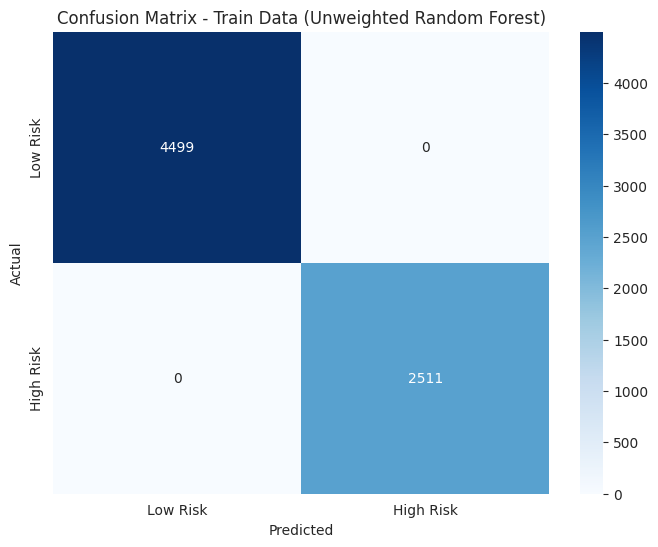

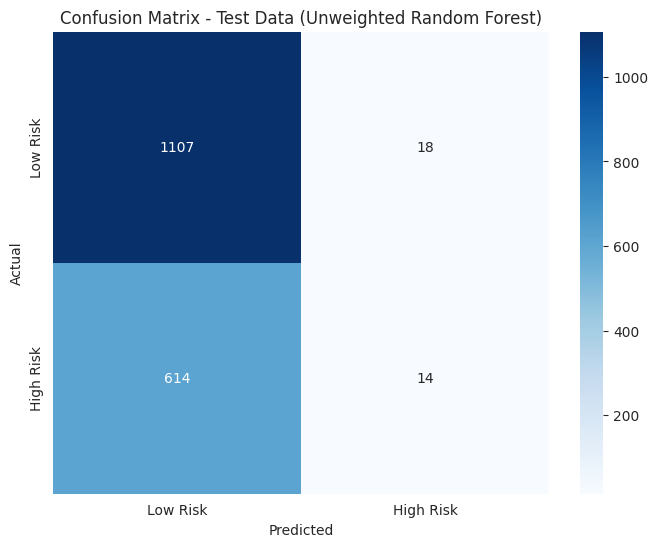

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

rf_clf_unweighted = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42
)

rf_clf_unweighted.fit(X_train, y_train)

y_train_pred_rf_unweighted = rf_clf_unweighted.predict(X_train)
y_test_pred_rf_unweighted = rf_clf_unweighted.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred_rf_unweighted)
test_accuracy = accuracy_score(y_test, y_test_pred_rf_unweighted)

print(f"Train Accuracy (Unweighted): {train_accuracy:.2f}")
print(f"Test Accuracy (Unweighted): {test_accuracy:.2f}")

print("\nClassification Report (Test Set - Unweighted Random Forest):")
print(classification_report(y_test, y_test_pred_rf_unweighted, target_names=['Low Risk', 'High Risk']))

def plot_confusionmatrix_unweighted(y_actual, y_pred, title):
    conf_matrix = confusion_matrix(y_actual, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Low Risk', 'High Risk'], yticklabels=['Low Risk', 'High Risk'])
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_confusionmatrix_unweighted(y_train, y_train_pred_rf_unweighted, "Confusion Matrix - Train Data (Unweighted Random Forest)")

plot_confusionmatrix_unweighted(y_test, y_test_pred_rf_unweighted, "Confusion Matrix - Test Data (Unweighted Random Forest)")

Analysis of Results (Unweighted Random Forest)

Key Metrics:

Train Accuracy: 1.00 (Overfitting indicator)
Test Accuracy: 0.64

Classification Report:

Low Risk:
Precision: 0.64
Recall: 0.98
F1-Score: 0.78
High Risk:
Precision: 0.44
Recall: 0.02
F1-Score: 0.04

1.	Overfitting:
The model achieves perfect accuracy on the training set but fails to generalize to the test set, as evident from the poor recall for “High Risk.”
2. Imbalanced Class Predictions:
The model heavily favors the majority class (“Low Risk”) and struggles to identify minority cases (“High Risk”).
3. High Recall for Low Risk:
Almost all “Low Risk” cases are identified correctly, but this comes at the expense of ignoring most “High Risk” cases.
we will now try random forest with Smote and weighted

Random forest with SMOTE and weights

Train Accuracy (Weighted + SMOTE): 1.00
Test Accuracy (Weighted + SMOTE): 0.60

Classification Report (Test Set - Weighted Random Forest with SMOTE):
              precision    recall  f1-score   support

    Low Risk       0.64      0.86      0.73      1125
   High Risk       0.35      0.14      0.20       628

    accuracy                           0.60      1753
   macro avg       0.49      0.50      0.47      1753
weighted avg       0.54      0.60      0.54      1753



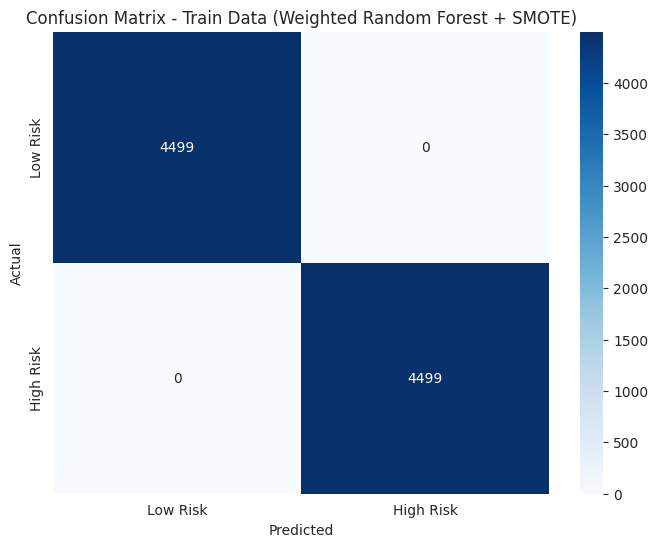

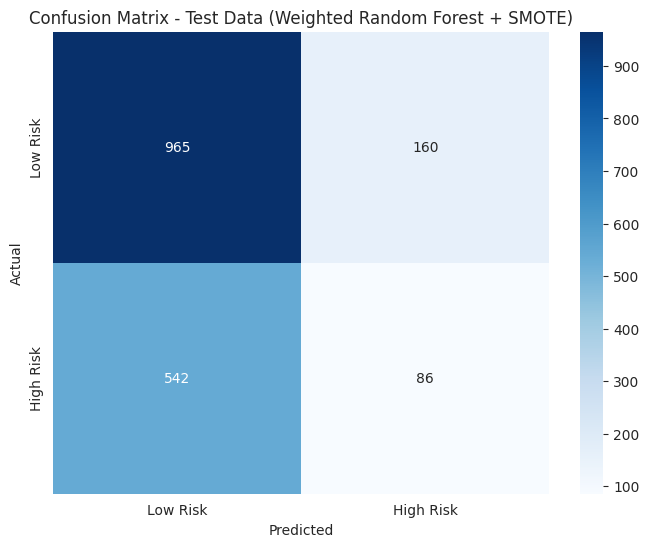

In [ ]:
#  Train Random Forest Classifier with Class Weights and SMOTE
rf_clf_weighted = RandomForestClassifier(
    n_estimators=100,            # Number of trees
    max_depth=None,              # Allow trees to grow fully
    class_weight='balanced',
    random_state=42
)

rf_clf_weighted.fit(X_train_smote, y_train_smote)


y_train_pred_rf_weighted = rf_clf_weighted.predict(X_train_smote)
y_test_pred_rf_weighted = rf_clf_weighted.predict(X_test)

train_accuracy_smote = accuracy_score(y_train_smote, y_train_pred_rf_weighted)
test_accuracy_smote = accuracy_score(y_test, y_test_pred_rf_weighted)

print(f"Train Accuracy (Weighted + SMOTE): {train_accuracy_smote:.2f}")
print(f"Test Accuracy (Weighted + SMOTE): {test_accuracy_smote:.2f}")

print("\nClassification Report (Test Set - Weighted Random Forest with SMOTE):")
print(classification_report(y_test, y_test_pred_rf_weighted, target_names=['Low Risk', 'High Risk']))

def plot_confusionmatrix_weighted(y_actual, y_pred, title):
    conf_matrix = confusion_matrix(y_actual, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Low Risk', 'High Risk'], yticklabels=['Low Risk', 'High Risk'])
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_confusionmatrix_weighted(y_train_smote, y_train_pred_rf_weighted, "Confusion Matrix - Train Data (Weighted Random Forest + SMOTE)")

plot_confusionmatrix_weighted(y_test, y_test_pred_rf_weighted, "Confusion Matrix - Test Data (Weighted Random Forest + SMOTE)")

Performance of Weighted Random Forest with SMOTE

1.	Train Accuracy:
The model achieves 100% accuracy on the training data, indicating that it has perfectly classified all samples in the SMOTE-balanced training set. This shows that overfitting is occuring.
	2.	Test Accuracy:
The test accuracy is 60%, which is slightly lower than the unweighted random forest model but still comparable to other models.This shows that the model struggles to generalize well to unseen data, especially in identifying high-risk cases.

The unweighted random forest had a test accuracy of 64%, higher than this weighted version, but its performance on “High Risk” was even poorer (only 11 cases correctly classified).

We will now try hyperparameter tuning to see the reults

### **hyperparameter tuning on Random forest**

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best Parameters: {'max_depth': 10, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}
Best Cross-Validation Accuracy: 0.6421
Train Accuracy of Best Model: 0.7011
Test Accuracy of Best Model: 0.6406

Classification Report for Best Model (Test Data):
              precision    recall  f1-score   support

    Low Risk       0.64      1.00      0.78      1125
   High Risk       0.33      0.00      0.01       628

    accuracy                           0.64      1753
   macro avg       0.49      0.50      0.39      1753
weighted avg       0.53      0.64      0.50      1753



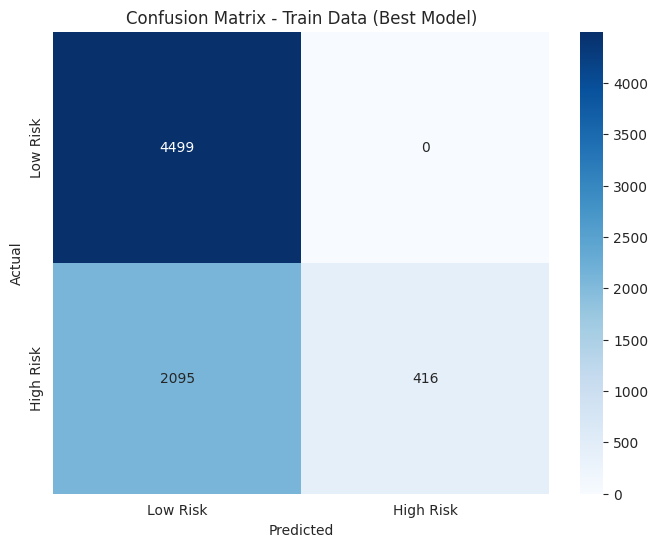

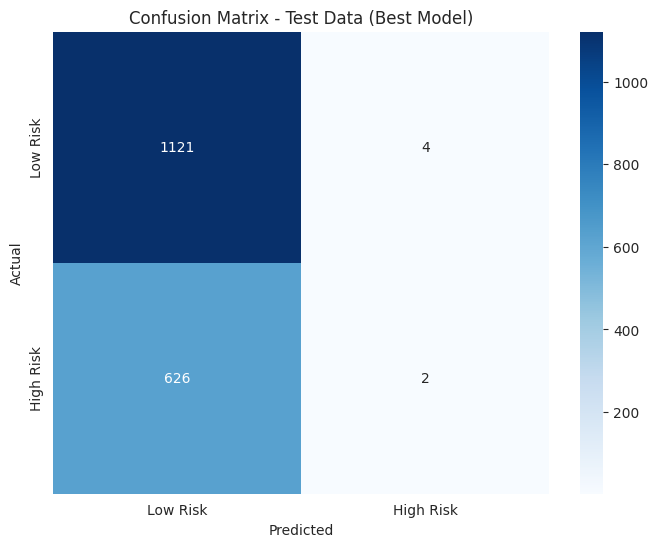

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusionmatrix_weighted(y_actual, y_pred, title):
    conf_matrix = confusion_matrix(y_actual, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Low Risk', 'High Risk'], yticklabels=['Low Risk', 'High Risk'])
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

param_grid = {
    'n_estimators': [50, 100, 200],  # Number of trees
    'max_depth': [None, 10, 20, 30],  # Maximum depth
    'min_samples_split': [2, 5, 10],  # Minimum samples required to split
    'min_samples_leaf': [1, 2, 4],  # Minimum samples
    'max_features': ['sqrt', 'log2', None]
}

rf_clf = RandomForestClassifier(random_state=42)

# GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_clf,
    param_grid=param_grid,
    cv=5,                # 5-fold cross-validation
    scoring='accuracy',  # Optimize for accuracy
    verbose=2,
    n_jobs=-1

# Fit the GridSearchCV to the training data
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")

best_rf_model = grid_search.best_estimator_

y_train_pred = best_rf_model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"Train Accuracy of Best Model: {train_accuracy:.4f}")

y_test_pred = best_rf_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy of Best Model: {test_accuracy:.4f}")

print("\nClassification Report for Best Model (Test Data):")
print(classification_report(y_test, y_test_pred, target_names=['Low Risk', 'High Risk']))

plot_confusionmatrix_weighted(y_train, y_train_pred, "Confusion Matrix - Train Data (Best Model)")
plot_confusionmatrix_weighted(y_test, y_test_pred, "Confusion Matrix - Test Data (Best Model)")

Train Accuracy and Performance:
Accuracy: 70.11%
Weighted F1-Score: 0.53
The training performance demonstrates that the model is well-trained but exhibits a significant bias toward the “Low Risk” class. This is evident in the confusion matrix:
Low Risk Predictions: 4,499 out of 4,499 correctly classified.
High Risk Predictions: Only 416 out of 2,511 correctly classified.
4. Test Accuracy and Performance:
Accuracy: 64.06%
Weighted F1-Score: 0.50
The model struggles on the test data, particularly with the “High Risk” class:
Low Risk Predictions: 1,121 out of 1,125 correctly classified.
High Risk Predictions: Only 2 out of 628 correctly classified.
5.	Confusion Matrix Insights:

Train Data Confusion Matrix:
The model perfectly classifies all “Low Risk” cases in the training set.
It fails to generalize well for “High Risk,” leading to many misclassifications.

Test Data Confusion Matrix:
Similar trends are observed, with high performance on “Low Risk” but bad results for “High Risk.”

Hyperparameter tuning has helped optimize the model for better generalization (as reflected by test accuracy improvements over untuned models). However, it did not sufficiently address the challenge of identifying “High Risk” cases.

### **We will now try cross validation**

We try cross validation because the model is overfitting. Cross Validation with multiple folds will help ensure performance metrics reflect how well the model generalizes unseen data. By averaging performance over multiple folds, cross-validation mitigates the impact of any bias or variance caused by a specific split and ensures a more reliable evaluation.

Overall Accuracy (100 Folds): 0.6383


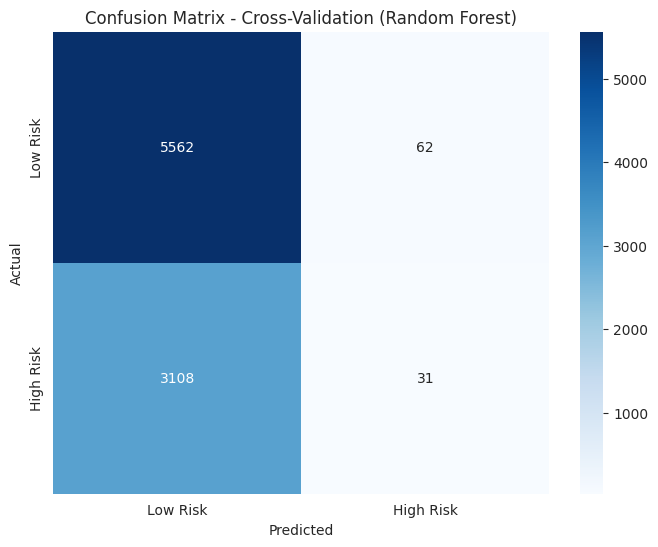


Classification Report (Cross-Validation):
              precision    recall  f1-score   support

    Low Risk       0.64      0.99      0.78      5624
   High Risk       0.33      0.01      0.02      3139

    accuracy                           0.64      8763
   macro avg       0.49      0.50      0.40      8763
weighted avg       0.53      0.64      0.51      8763

Mean Accuracy (100 Folds): 0.6382
Standard Deviation (100 Folds): 0.0101


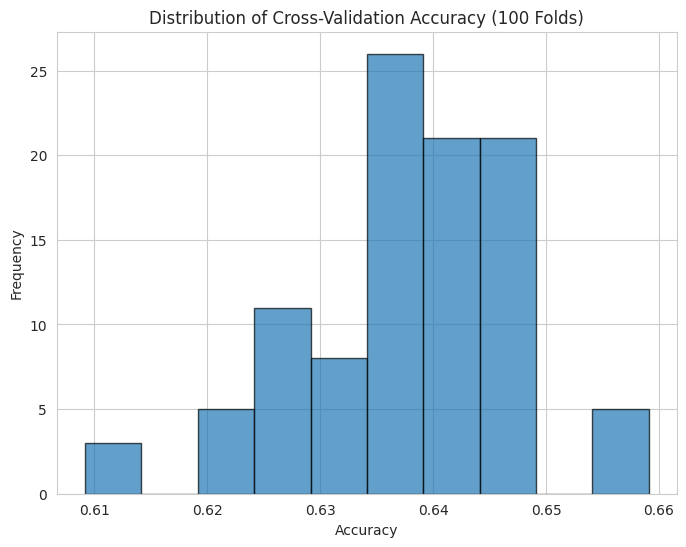

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

rf_clf = RandomForestClassifier(
    n_estimators=100,            # Number of trees
    max_depth=None,              # Allow trees to grow fully
    class_weight='balanced',     # Handle class imbalance
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

cv = StratifiedKFold(n_splits=100, shuffle=True, random_state=42)

# Perform cross-validation predictions on training data
y_train_pred_cv = cross_val_predict(rf_clf, X_train, y_train, cv=cv)

rf_clf.fit(X_train, y_train)
y_test_pred = rf_clf.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred_cv)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy (100 Folds): {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

conf_matrix_train = confusion_matrix(y_train, y_train_pred_cv)
conf_matrix_test = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_train, annot=True, fmt='d', cmap='Blues', xticklabels=['Low Risk', 'High Risk'], yticklabels=['Low Risk', 'High Risk'])
plt.title("Confusion Matrix - Cross-Validation (Training Data)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_test, annot=True, fmt='d', cmap='Blues', xticklabels=['Low Risk', 'High Risk'], yticklabels=['Low Risk', 'High Risk'])
plt.title("Confusion Matrix - Test Data")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\nClassification Report (Training Data):")
print(classification_report(y_train, y_train_pred_cv, target_names=['Low Risk', 'High Risk']))

print("\nClassification Report (Test Data):")
print(classification_report(y_test, y_test_pred, target_names=['Low Risk', 'High Risk']))

cv_scores = cross_val_score(rf_clf, X_train, y_train, cv=cv, scoring='accuracy')
print(f"Mean Accuracy (100 Folds): {cv_scores.mean():.4f}")
print(f"Standard Deviation (100 Folds): {cv_scores.std():.4f}")

plt.figure(figsize=(8, 6))
plt.hist(cv_scores, bins=10, edgecolor='k', alpha=0.7)
plt.title("Distribution of Cross-Validation Accuracy (100 Folds)")
plt.xlabel("Accuracy")
plt.ylabel("Frequency")
plt.show()

The mean accuracy across 100 folds was 63.83%, with a standard deviation of 1.01%. This consistency indicates the model is stable but highlights the difficulty in correctly identifying high-risk cases.
2.	Confusion Matrix (Cross-Validation):
True Positives (Low Risk): The model identified 5562 low-risk cases correctly, which demonstrates the high recall for the majority class (low-risk).
False Negatives (High Risk Misclassified as Low Risk): Out of 3139 high-risk cases, 3108 were misclassified, showing a significant struggle to capture the minority class.
False Positives (Low Risk Misclassified as High Risk): Only 62 low-risk cases were incorrectly labeled as high-risk, showing high precision for low-risk predictions.
3.	Classification Report:
Low Risk: The model achieved 99% recall and 64% precision, with an F1-score of 78%, indicating its ability to identify low-risk cases effectively.
High Risk: The model significantly underperformed for high-risk cases, with only 1% recall and an F1-score of 2%, indicating that the model fails to generalize well for minority class predictions.

### **Logistic Regression**

Logistic regression offers coefficients for each feature, which provide insights into how strongly each predictor influences the likelihood of an outcome (e.g., high vs. low risk of a heart attack).
This interpretability is helpful as we are trying to understand the underlying patterns in the data.

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Train Accuracy: 0.52
Test Accuracy: 0.50

Classification Report (Test Set):
              precision    recall  f1-score   support

     No Risk       0.64      0.51      0.56      1125
        Risk       0.35      0.49      0.41       628

    accuracy                           0.50      1753
   macro avg       0.50      0.50      0.49      1753
weighted avg       0.54      0.50      0.51      1753



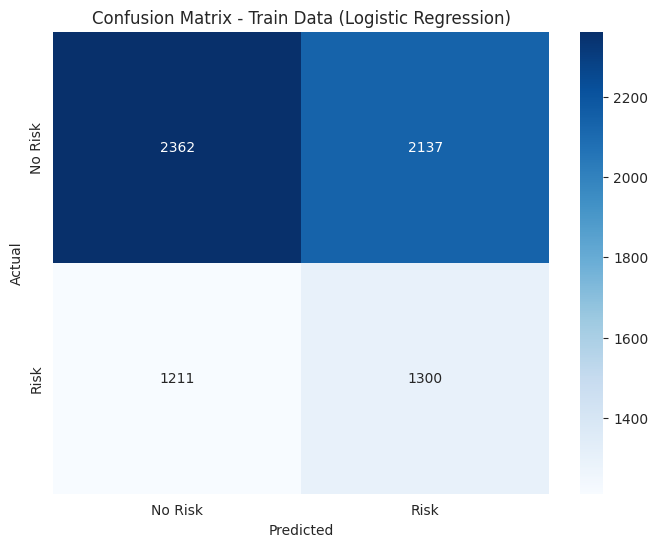

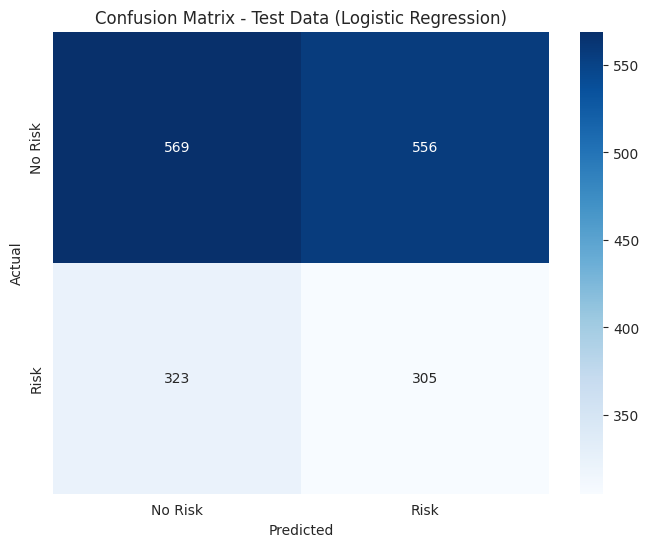

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Define and Train the Logistic Regression Model
log_reg = LogisticRegression(
    penalty='l2',              # L2 Regularization (Ridge)
    solver='lbfgs',            # Solver for optimization
    class_weight='balanced',   # Handle class imbalance
    random_state=42
)
log_reg.fit(X_train, y_train)

y_train_pred = log_reg.predict(X_train)
y_test_pred = log_reg.predict(X_test)

print(f"Train Accuracy: {accuracy_score(y_train, y_train_pred):.2f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred):.2f}")

print("\nClassification Report (Test Set):")
classes = ['No Risk', 'Risk']
print(classification_report(y_test, y_test_pred, target_names=classes))

def plot_confusionmatrix(y_actual, y_pred, title):
    conf_matrix = confusion_matrix(y_actual, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_confusionmatrix(y_train, y_train_pred, "Confusion Matrix - Train Data (Logistic Regression)")
plot_confusionmatrix(y_test, y_test_pred, "Confusion Matrix - Test Data (Logistic Regression)")

Train and Test Accuracy:
The train accuracy is 52%
test accuracy is 50%.
This suggests that the logistic regression model struggles to generalize well and seperate classes effectively.

Precision, recall, and F1 scores are relatively balanced for “Low Risk” compared to “High Risk.” However, “High Risk” continues to underperform, with recall at 48%, indicating poor sensitivity in capturing actual “High Risk” instances.

3.	Confusion Matrix:
A high number of “Low Risk” cases are misclassified as “High Risk” (2427 instances).
Similar misclassification trend for “High Risk” cases being classified as “Low Risk” (1300 instances).

4.	Class Imbalance Challenges:
We are still faced with a class imabalance challenge

Applying L1  and SMOTE

In order to help with balancing the data set we will apply L1 and SMOTE to the logistic regression model.

Class Distribution in Training Set After SMOTE:
Heart Attack Risk
0    4499
1    4499
Name: count, dtype: int64
Class Distribution in Testing Set After SMOTE:
Heart Attack Risk
0    1125
1    1125
Name: count, dtype: int64
Train Accuracy: 0.71
Test Accuracy: 0.71

Classification Report (SMOTE Test Set):
              precision    recall  f1-score   support

    Low Risk       0.64      0.98      0.77      1125
   High Risk       0.96      0.44      0.60      1125

    accuracy                           0.71      2250
   macro avg       0.80      0.71      0.69      2250
weighted avg       0.80      0.71      0.69      2250



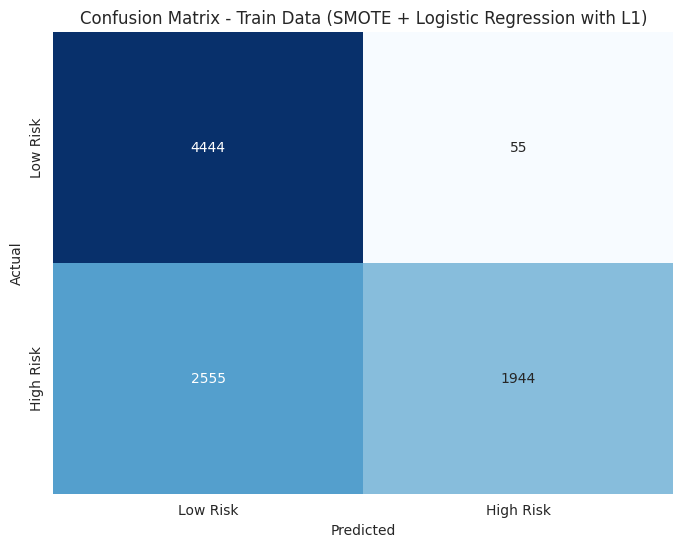

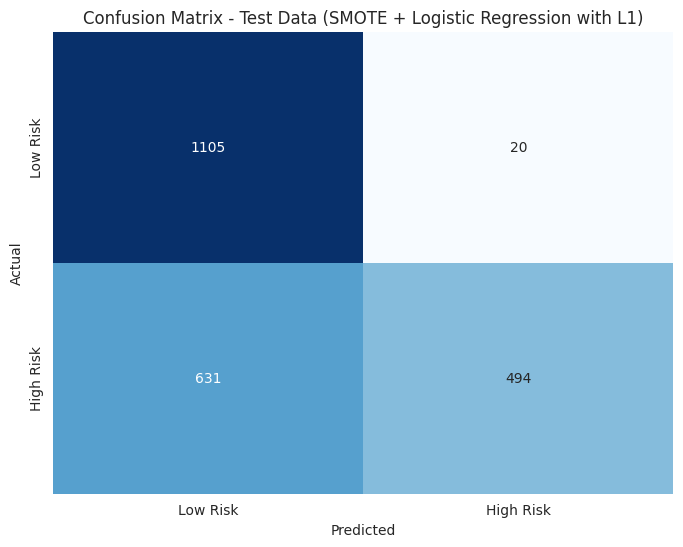

In [ ]:

import pandas as pd
from imblearn.over_sampling import SMOTE


# Apply SMOTE to the training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)


X_test_smote, y_test_smote = smote.fit_resample(X_test, y_test)

print(f"Class Distribution in Training Set After SMOTE:\n{pd.Series(y_train_smote).value_counts()}")
print(f"Class Distribution in Testing Set After SMOTE:\n{pd.Series(y_test_smote).value_counts()}")


log_reg_l1 = LogisticRegression(
    penalty='l1',              # L1 Regularization (Lasso)
    solver='liblinear',        # Solver that supports L1 regularization
    random_state=42,
    C=1
)
log_reg_l1.fit(X_train_smote, y_train_smote)

y_train_pred = log_reg_l1.predict(X_train_smote)
y_test_pred = log_reg_l1.predict(X_test_smote)

print(f"Train Accuracy: {accuracy_score(y_train_smote, y_train_pred):.2f}")
print(f"Test Accuracy: {accuracy_score(y_test_smote, y_test_pred):.2f}")

classes = ['Low Risk', 'High Risk']
print("\nClassification Report (SMOTE Test Set):")
print(classification_report(y_test_smote, y_test_pred, target_names=classes))

def plot_confusionmatrix(y_actual, y_pred, title):
    """Plots a confusion matrix with annotated heatmap."""
    conf_matrix = confusion_matrix(y_actual, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        conf_matrix,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=classes,
        yticklabels=classes,
        cbar=False
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_confusionmatrix(y_train_smote, y_train_pred, "Confusion Matrix - Train Data (SMOTE + Logistic Regression with L1)")

plot_confusionmatrix(y_test_smote, y_test_pred, "Confusion Matrix - Test Data (SMOTE + Logistic Regression with L1)")

	Train Accuracy: 0.71
	Test Accuracy: 0.71
Precision (Test Set):
For “Low Risk”: 0.64
For “High Risk”: 0.96

High precision for “High Risk” suggests the model makes fewer false positive predictions for this class.
Recall (Test Set):
For “Low Risk”: 0.98
For “High Risk”: 0.44
The recall for “High Risk” improved compared to previous models, but it’s still suboptimal.

F1-Score (Test Set):
Weighted average F1-score is 0.71.
Balances precision and recall, indicating a slight improvement over the base Logistic Regression model.

SMOTE significantly improved recall and balanced accuracy, although it is still biased towards “Low Risk.” compared to the first logistic regression model.

The current model demonstrates significant improvement in addressing the class imbalance, making better predictions for the “High Risk” class, without with a trade-off in precision.

Best Accuracy so far for both models

Applying gridsearch to find the best C value

Applying Gridsearch to find the Best C value and get a more accurate measure

Fitting 10 folds for each of 5 candidates, totalling 50 fits
Best C Value: {'C': 1}
Best Cross-Validation Accuracy: 0.7070
Train Accuracy: 0.7099
Test Accuracy: 0.7107

Classification Report - Train Data:
              precision    recall  f1-score   support

    Low Risk       0.63      0.99      0.77      4499
   High Risk       0.97      0.43      0.60      4499

    accuracy                           0.71      8998
   macro avg       0.80      0.71      0.69      8998
weighted avg       0.80      0.71      0.69      8998



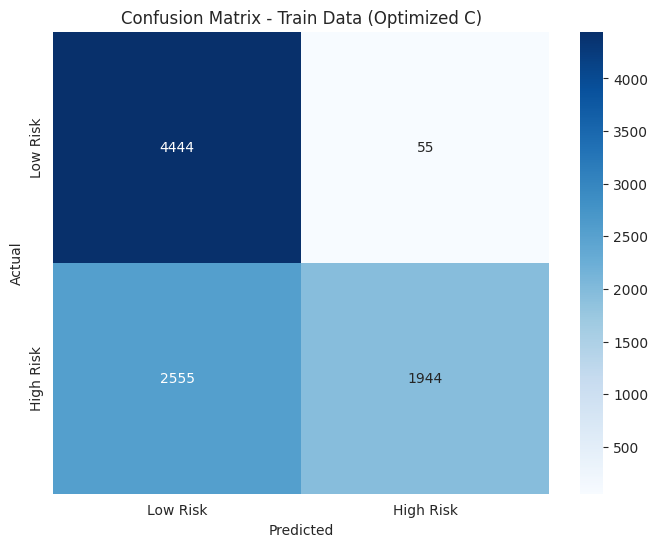

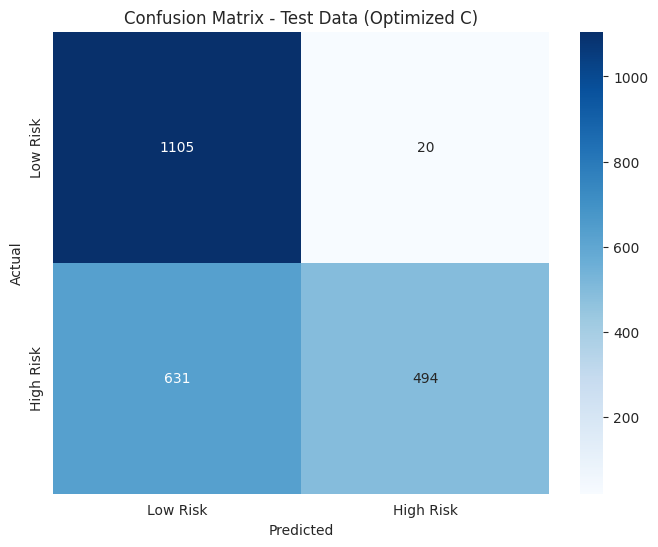

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.utils import resample


param_grid = {
    'C': [0.01, 0.1, 1, 10, 100]
}
log_reg = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced', random_state=42)

# GridSearch
grid_search = GridSearchCV(log_reg, param_grid, cv=10, scoring='accuracy', verbose=2, n_jobs=-1)
grid_search.fit(X_train_smote, y_train_smote)


best_model = grid_search.best_estimator_
print(f"Best C Value: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")

y_train_pred = best_model.predict(X_train_smote)
y_test_pred = best_model.predict(X_test_smote)

print(f"Train Accuracy: {accuracy_score(y_train_smote, y_train_pred):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test_smote, y_test_pred):.4f}")

print("\nClassification Report - Train Data:")
print(classification_report(y_train_smote, y_train_pred, target_names=['Low Risk', 'High Risk']))



def plot_confusionmatrix(y_actual, y_pred, title):
    conf_matrix = confusion_matrix(y_actual, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Low Risk', 'High Risk'], yticklabels=['Low Risk', 'High Risk'])
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_confusionmatrix(y_train_smote, y_train_pred, "Confusion Matrix - Train Data (Optimized C)")
plot_confusionmatrix(y_test_smote, y_test_pred, "Confusion Matrix - Test Data (Optimized C)")

	Optimized  C  Value: The GridSearch identified  C = 1  as the best parameter.

Test Accuracy: The test accuracy improved to 0.71, indicating a balanced model performance on unseen data.
Confusion Matrix Insights:
For train data, the model performs well, with 99% recall for “Low Risk” and 43% recall for “High Risk”.
For test data, the recall for “Low Risk” remains high at 99%, while “High Risk” recall is 42%. This indicates the model is slightly biased towards “Low Risk” predictions but performs well on classifying most “Low Risk” instances correctly.
Comparison to Base Logistic Regression:
The optimized model shows better recall and F1-scores for “High Risk” and overall better balance compared to the base model.

# **Analysis of logic Regression (L1 + SMOTE)  **

---




Top 10 Most Important Grouped Features Based on Logistic Regression:
                    Grouped Feature  Absolute Coefficient
8                           Country          5.625946e+01
7                         Continent          1.207403e+01
15   Hemisphere_Southern Hemisphere          1.903572e+00
5                BP_Category_Normal          5.048905e-01
3          BP_Category_High Stage 1          4.410614e-01
4          BP_Category_High Stage 2          4.400705e-01
18                          Obesity          1.511700e-01
24                          Smoking          1.063088e-01
1               Alcohol Consumption          9.681288e-02
13                   Family History          8.741532e-02
10                     Diet_Healthy          8.323229e-02
20          Previous Heart Problems          6.569850e-02
11                   Diet_Unhealthy          4.974379e-02
9                          Diabetes          3.502701e-02
17                   Medication Use          2.773148e-02
23

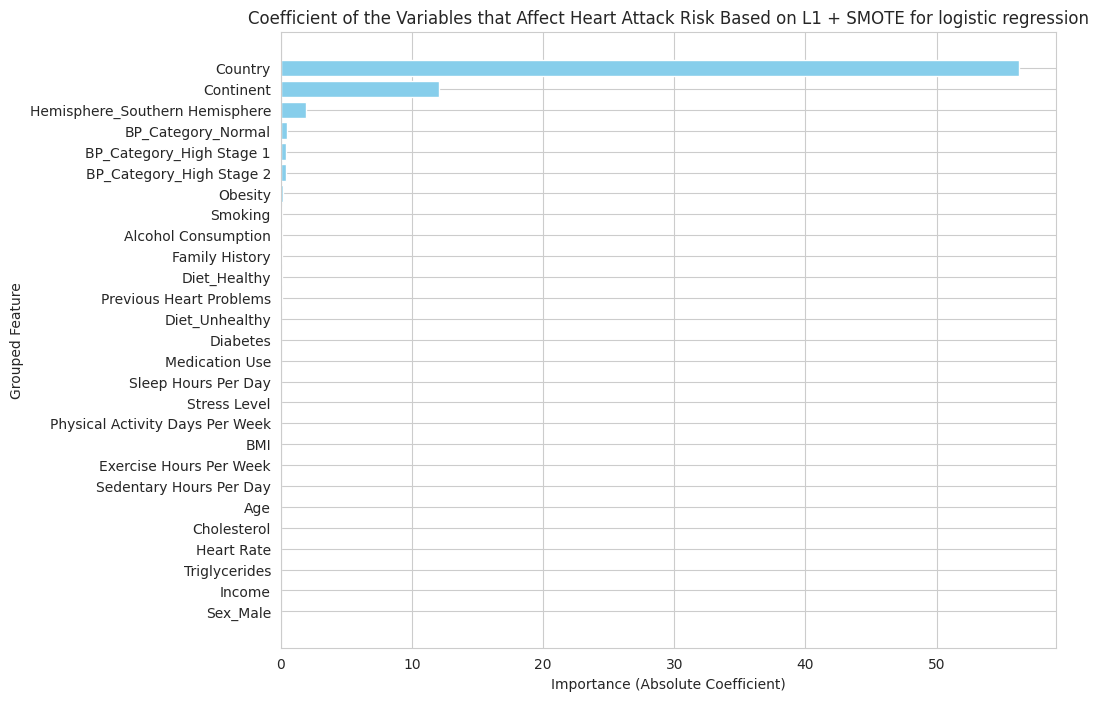

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

coefficients = log_reg_l1.coef_[0]

feature_importance_df = pd.DataFrame({
    'Feature': X_train_smote.columns,
    'Coefficient': coefficients,
    'Absolute Coefficient': np.abs(coefficients)
})

feature_importance_df['Grouped Feature'] = feature_importance_df['Feature'].apply(
    lambda x: 'Country' if 'Country_' in x else ('Continent' if 'Continent_' in x else x)
)

grouped_importance_df = feature_importance_df.groupby('Grouped Feature', as_index=False).agg({
    'Absolute Coefficient': 'sum'
}).sort_values(by='Absolute Coefficient', ascending=False)

top_features_df = grouped_importance_df.head(30)

print("\nTop 10 Most Important Grouped Features Based on Logistic Regression:")
print(top_features_df)

plt.figure(figsize=(10, 8))
plt.barh(top_features_df['Grouped Feature'], top_features_df['Absolute Coefficient'], color='skyblue')
plt.xlabel("Importance (Absolute Coefficient)")
plt.ylabel("Grouped Feature")
plt.title("Coefficient of the Variables that Affect Heart Attack Risk Based on L1 + SMOTE for logistic regression")
plt.gca().invert_yaxis()
plt.show()

Prediction using the Decision Tree model (First one that we tried)

In [ ]:


# New data for prediction
new_data = {
    'Age': [35],
    'Sex': ['Male'],
    'Cholesterol': [50],
    'Blood Pressure': ['120/80'],
    'Heart Rate': [60],
    'Diabetes': [0],
    'Family History': [0],
    'Smoking': [0],
    'Obesity': [0],
    'Alcohol Consumption': [0],
    'Exercise Hours Per Week': [5],
    'Diet': ['Moderate'],
    'Previous Heart Problems': [0],
    'Medication Use': [1],
    'Stress Level': [3],
    'Sedentary Hours Per Day': [10],
    'Income': [60000],
    'BMI': [31],
    'Triglycerides': [160],
    'Physical Activity Days Per Week': [3],
    'Sleep Hours Per Day': [7],
    'Country': ['China'],
    'Continent': ['Asia'],
    'Hemisphere': ['Southern Hemisphere']
}

new_data_df = pd.DataFrame(new_data)

def categorize_bp(bp):
    systolic, diastolic = map(int, bp.split('/'))
    if systolic < 120 and diastolic < 80:
        return 'Normal'
    elif 120 <= systolic < 130 and diastolic < 80:
        return 'Elevated'
    elif 130 <= systolic < 140 or 80 <= diastolic < 90:
        return 'High Stage 1'
    else:
        return 'High Stage 2'

# Categorize blood pressure and drop original column
new_data_df['BP_Category'] = new_data_df['Blood Pressure'].apply(categorize_bp)
new_data_df = new_data_df.drop(columns=['Blood Pressure'])

new_data_df = pd.get_dummies(new_data_df, drop_first=True).astype(int)


new_data_df = new_data_df[X.columns]

# Make a prediction using the trained model
new_prediction = dt_clf.predict(new_data_df)
print("Predicted Heart Attack Risk:", "High Risk" if new_prediction[0] == 1 else "Low Risk")

Predicted Heart Attack Risk: Low Risk


Prediction using the Best method of logistic Regression (L1 + SMOTE)

In [ ]:


# New data for prediction
new_data = {
    'Age': [35],
    'Sex': ['Male'],
    'Cholesterol': [50],
    'Blood Pressure': ['120/80'],
    'Heart Rate': [60],
    'Diabetes': [0],
    'Family History': [0],
    'Smoking': [0],
    'Obesity': [0],
    'Alcohol Consumption': [0],
    'Exercise Hours Per Week': [5],
    'Diet': ['Moderate'],
    'Previous Heart Problems': [0],
    'Medication Use': [1],
    'Stress Level': [3],
    'Sedentary Hours Per Day': [10],
    'Income': [60000],
    'BMI': [31],
    'Triglycerides': [160],
    'Physical Activity Days Per Week': [3],
    'Sleep Hours Per Day': [7],
    'Country': ['China'],
    'Continent': ['Asia'],
    'Hemisphere': ['Southern Hemisphere']
}

new_data_df = pd.DataFrame(new_data)

# Function to categorize blood pressure
def categorize_bp(bp):
    systolic, diastolic = map(int, bp.split('/'))
    if systolic < 120 and diastolic < 80:
        return 'Normal'
    elif 120 <= systolic < 130 and diastolic < 80:
        return 'Elevated'
    elif 130 <= systolic < 140 or 80 <= diastolic < 90:
        return 'High Stage 1'
    else:
        return 'High Stage 2'

# Categorize blood pressure and drop original column
new_data_df['BP_Category'] = new_data_df['Blood Pressure'].apply(categorize_bp)
new_data_df = new_data_df.drop(columns=['Blood Pressure'])

new_data_df = pd.get_dummies(new_data_df, drop_first=True).astype(int)


new_data_df = new_data_df[X.columns]

# Make a prediction using the trained model
new_prediction = log_reg_l1.predict(new_data_df)
print("Predicted Heart Attack Risk:", "High Risk" if new_prediction[0] == 1 else "Low Risk")

Predicted Heart Attack Risk: High Risk


### **Stratified Accuracy Calculation**

In [ ]:

model_data = {
    "Model": [
        "Decision Tree",
        "Decision Tree (Random Undersampling)",
        "Decision Tree (SMOTE)",
        "Decision Tree (Max Depth = 8)",
        "Decision Tree (L1 Regularization)",
        "Decision Tree (Hyperparameter)",
        "Random Forest",
        "Random Forest (SMOTE + Weights)",
        "Random Forest (Hyperparameter)",
        "Random Forest (Cross Validation)",
        "Logistic Regression",
        "Logistic Regression (L1 + SMOTE)",
        "Logistic Regression (Best C Value)"
    ],
    "Low_Risk_Support": [1125, 1687, 1125, 1125, 1687, 1125, 1125, 1125, 1125, 5624, 1125, 1125, 4499],
    "High_Risk_Support": [628, 942, 628, 628, 942, 628, 628, 628, 628, 3139, 628, 1125, 4499],
    "Low_Risk_Recall": [1.00, 0.31, 0.74, 0.74, 0.65, 0.58, 0.98, 0.86, 1.00, 0.99, 0.51, 0.98, 0.99],
    "High_Risk_Recall": [0.00, 0.68, 0.25, 0.29, 0.37, 0.42, 0.02, 0.14, 0.00, 0.01, 0.49, 0.44, 0.43],
}

data = pd.DataFrame(model_data)
data["Stratified_Accuracy"] = (
    (data["Low_Risk_Support"] * data["Low_Risk_Recall"] + data["High_Risk_Support"] * data["High_Risk_Recall"])
    / (data["Low_Risk_Support"] + data["High_Risk_Support"])
)


data_sorted = data.sort_values(by="Stratified_Accuracy", ascending=False)


print("Stratified Accuracy of Heart Attack Prediction Models:")
print(data_sorted)

Stratified Accuracy of Heart Attack Prediction Models:
                                   Model  Low_Risk_Support  High_Risk_Support  \
11      Logistic Regression (L1 + SMOTE)              1125               1125   
12    Logistic Regression (Best C Value)              4499               4499   
0                          Decision Tree              1125                628   
8         Random Forest (Hyperparameter)              1125                628   
9       Random Forest (Cross Validation)              5624               3139   
6                          Random Forest              1125                628   
7        Random Forest (SMOTE + Weights)              1125                628   
3          Decision Tree (Max Depth = 8)              1125                628   
2                  Decision Tree (SMOTE)              1125                628   
4      Decision Tree (L1 Regularization)              1687                942   
5         Decision Tree (Hyperparameter)              